In [ ]:
# repo-root bootstrap — relative data/ paths resolve from any kernel cwd
import os, pathlib
_root = pathlib.Path.cwd()
while not (_root / 'pyproject.toml').exists() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
print('cwd ->', _root)

# Baseline Comparison: ACC vs Classical Topic Modeling

Compares eight methods on the same EMNLP 2020+2025 corpus:
- **LDA** (Latent Dirichlet Allocation, gensim)
- **NMF** (Non-negative Matrix Factorization, sklearn)
- **BERTopic-SPECTER2** (with SPECTER2 embeddings aligned to the ACC setup)
- **BERTopic-general (MPNet)** (BERTopic over general-purpose all-mpnet-base-v2 embeddings)
- **SentSPECTER** (same clustering pipeline as ACC, but over abstract sentences)
- **SentSPECTER-top30** (SentSPECTER restricted to the 30 most populated clusters)
- **ACC** (our method, clustering over claim-level SPECTER2 embeddings)
- **ACC-top30** (ACC restricted to the 30 most populated clusters)

**Evaluation metrics:**
1. Topic Coherence C_v and NPMI (intrinsic quality)
2. Topic Diversity (% unique top-10 words across all topics)
3. Data-driven SToP alignment (soft purity, LRAP, nDCG@k, V-measure, PairF1)
4. Temporal drift signal: top growing/declining themes 2020→2025

All methods are compared at **document level** using soft or multi-label topic
assignment, matching the multi-label structure of SToP paper annotations.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

In [2]:
DATA_DIR = Path('.')
RESULTS_DIR = DATA_DIR / 'data' / 'claims'
CLUSTERS_DIR = DATA_DIR / 'data' / 'clusters'
RAW_DIR = DATA_DIR / 'data' / 'raw'
ARTIFACTS_DIR = DATA_DIR / 'artifacts' / 'baseline'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_TOPICS = 30  # Fixed at 30 for fair comparison with top-30 clustering variants

## 1. Data Loading

In [3]:
RAW_ABSTRACTS_PATH = RAW_DIR / 'emnlp_papers_raw.csv'
HAS_RAW = RAW_ABSTRACTS_PATH.exists()
if not (HAS_RAW):
    print('[skipped] data/raw/emnlp_papers_raw.csv not shipped in the public bundle — see README §Data')
else:
    # Raw abstracts
    df_papers = pd.read_csv(RAW_DIR / 'emnlp_papers_raw.csv')
    df_papers = df_papers.dropna(subset=['abstract']).copy()
    df_papers['abstract'] = df_papers['abstract'].str.strip()
    df_papers = df_papers[df_papers['abstract'].str.len() > 50]  # Remove near-empty abstracts

    print(f'Papers loaded: {len(df_papers)}')
    print(f'Years: {df_papers["year"].value_counts().sort_index().to_dict()}')
    print(f'Columns: {df_papers.columns.tolist()}')
    display(df_papers.head(2))

Papers loaded: 6517
Years: {2020: 751, 2021: 847, 2022: 826, 2023: 1047, 2024: 1237, 2025: 1809}
Columns: ['paper_id', 'year', 'title', 'abstract', 'url']


,paper_id,year,title,abstract,url
0,2020.emnlp-main.1,2020,Detecting Attackable Sentences in Arguments,Finding attackable sentences in an argument is...,https://aclanthology.org/2020.emnlp-main.1/
1,2020.emnlp-main.2,2020,Extracting Implicitly Asserted Propositions in...,Argumentation accommodates various rhetorical ...,https://aclanthology.org/2020.emnlp-main.2/


In [4]:
from pathlib import Path
import pandas as pd

RESULTS_DIR = globals().get('RESULTS_DIR', Path('data/claims'))
CLUSTERS_DIR = globals().get('CLUSTERS_DIR', Path('data/clusters'))
RANDOM_STATE = globals().get('RANDOM_STATE', 42)
BALANCED_SAMPLE_YEARS = list(range(2020, 2026))
TARGET_PAPERS_PER_YEAR = 748

# ACC extracted claims (OpenRouter format from extraction.ipynb)
CLAIMS_FILE = RESULTS_DIR / 'openrouter_claims.csv'
df_claims = pd.read_csv(CLAIMS_FILE)

# Compatibility layer: map common legacy claim-text column names to atomic_claim
if 'atomic_claim' not in df_claims.columns:
    legacy_text_cols = ['claim', 'extracted_claim', 'text']
    found_legacy = next((c for c in legacy_text_cols if c in df_claims.columns), None)
    if found_legacy is not None:
        df_claims = df_claims.rename(columns={found_legacy: 'atomic_claim'})

required_claim_cols = {'paper_id', 'year', 'atomic_claim'}
missing_claim_cols = required_claim_cols - set(df_claims.columns)
if missing_claim_cols:
    raise ValueError(
        f'Claims file {CLAIMS_FILE} is missing required columns: {sorted(missing_claim_cols)}'
    )

df_claims['year'] = pd.to_numeric(df_claims['year'], errors='coerce')
df_claims = df_claims[df_claims['year'].notna()].copy()
df_claims['year'] = df_claims['year'].astype(int)
df_claims = df_claims.dropna(subset=['atomic_claim']).copy()

def balance_claims_by_year(df, years, target_papers_per_year, random_seed=42):
    df = df[df['year'].isin(years)].copy()
    sampled_papers = []

    for year in years:
        year_papers = (
            df.loc[df['year'] == year, 'paper_id']
            .dropna()
            .drop_duplicates()
            .sort_values()
        )
        available_papers = len(year_papers)
        if available_papers < target_papers_per_year:
            raise ValueError(
                f'Year {year} has only {available_papers} unique papers, cannot sample {target_papers_per_year}.'
            )

        year_sample = year_papers.sample(n=target_papers_per_year, random_state=random_seed)
        sampled_papers.append(pd.DataFrame({'paper_id': year_sample.values, 'year': year}))

    sampled_papers = pd.concat(sampled_papers, ignore_index=True)
    df = df.merge(sampled_papers, on=['paper_id', 'year'], how='inner')

    balance_summary = (
        df.groupby('year')
        .agg(papers=('paper_id', 'nunique'), claims=('atomic_claim', 'size'))
        .reindex(years)
    )
    print('Balanced claims subset by year:')
    print(balance_summary.to_string())
    return df

df_claims = balance_claims_by_year(
    df_claims,
    years=BALANCED_SAMPLE_YEARS,
    target_papers_per_year=TARGET_PAPERS_PER_YEAR,
    random_seed=RANDOM_STATE,

)

print(f'Claims file: {CLAIMS_FILE.name}')
print(f'Claims loaded: {len(df_claims)}')

Balanced claims subset by year:
      papers  claims
year                
2020     748    2678
2021     748    2606
2022     748    2791
2023     748    2738
2024     748    2762
2025     748    3001
Claims file: openrouter_claims.csv
Claims loaded: 16576


In [5]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    # ── Evaluation subset: papers that have ≥1 extracted claim ───────────────────
    # Training: LDA/NMF/BERTopic use full df_papers — maximum training data.
    # Evaluation: ALL metrics computed on df_eval only, so the comparison is on the
    # same set of documents regardless of method.
    eval_paper_ids = set(df_claims['paper_id'].unique())
    df_eval = df_papers[df_papers['paper_id'].isin(eval_paper_ids)].reset_index(drop=True)
    eval_mask = df_papers['paper_id'].isin(eval_paper_ids).values   # bool (len(df_papers),)

    print(f'Full corpus:  {len(df_papers)} papers')
    print(f'df_eval:      {len(df_eval)} papers with ≥1 claim '
          f'({len(df_eval)/len(df_papers)*100:.1f}% of corpus)')
    print(f'Years in df_eval: {df_eval["year"].value_counts().sort_index().to_dict()}')
    assert eval_mask.sum() == len(df_eval), 'eval_mask mismatch!'


Full corpus:  6517 papers
df_eval:      4488 papers with ≥1 claim (68.9% of corpus)
Years in df_eval: {2020: 748, 2021: 748, 2022: 748, 2023: 748, 2024: 748, 2025: 748}


In [6]:
STOP_TAXONOMY_PATH = DATA_DIR / 'data/external/STop_topic_classification_dataset_for_scientific_papers.csv'
HAS_STOP = STOP_TAXONOMY_PATH.exists()
if not (HAS_STOP):
    print('[skipped] data/external SToP taxonomy not shipped in the public bundle — see README §Data')
else:
    # SToP ground-truth taxonomy (multi-label)
    df_stop = pd.read_csv(DATA_DIR / 'data/external/STop_topic_classification_dataset_for_scientific_papers.csv')

    print(f'SToP shape: {df_stop.shape}')
    print(f'Columns: {df_stop.columns.tolist()}')
    display(df_stop.head(3))

SToP shape: (2545, 12)
Columns: ['Labels', 'Paper Name', 'Conference', 'File Path', 'Intro Concl', 'Abstract', 'Whole Extract', 'Train_test_0', 'Train_test_1', 'Train_test_2', 'Train_test_3', 'Train_test_4']


,Labels,Paper Name,Conference,File Path,Intro Concl,Abstract,Whole Extract,Train_test_0,Train_test_1,Train_test_2,Train_test_3,Train_test_4
0,"Linguistic Theories, Cognitive Modeling and Ps...",a systematic assessment of syntactic generaliz...,ACL2020,./Data/Base_JSON\prefixA\json\acl/2020.acl-mai...,A growing body of work advocates that assessme...,While state-of-the-art neural network models c...,"{'paper_id': '2020', 'header': {'generated_wit...",Test,Train,Train,Train,Train
1,"Linguistic Theories, Cognitive Modeling and Ps...",learning to understand child-directed and adul...,ACL2020,./Data/Base_JSON\prefixA\json\acl/2020.acl-mai...,Speech directed to children (CDS) differs from...,Speech directed to children differs from adult...,"{'paper_id': '2020', 'header': {'generated_wit...",Train,Test,Train,Train,Train
2,"Linguistic Theories, Cognitive Modeling and Ps...",speakers enhance contextually confusable words,ACL2020,./Data/Base_JSON\prefixA\json\acl/2020.acl-mai...,A major open question in the study of natural ...,Recent work has found evidence that natural la...,"{'paper_id': '2020', 'header': {'generated_wit...",Train,Train,Train,Test,Train


In [7]:
if not (HAS_STOP):
    print('[skipped] depends on data/external SToP taxonomy (absent in the public bundle) — see README §Data')
else:
    # Inspect SToP labels structure
    print("Unique labels count:", df_stop['Labels'].nunique())
    print("\nAll unique labels:")
    for lbl in sorted(df_stop['Labels'].unique()):
        print(f"  {repr(lbl)}")
    print("\nPaper Name samples:")
    print(df_stop['Paper Name'].head(5).tolist())
    print("\nConferences:", df_stop['Conference'].unique())

Unique labels count: 21

All unique labels:
  'Computational Social Science and Social Media'
  'Dialogue and Interactive Systems'
  'Discourse and Pragmatics'
  'Ethics and NLP'
  'Generation'
  'Information Extraction'
  'Information Retrieval and Text Mining'
  'Interpretability and Analysis of Models for NLP'
  'Language Grounding to Vision, Robotics and Beyond'
  'Linguistic Theories, Cognitive Modeling and Psycholinguistics'
  'Machine Learning for NLP'
  'Machine Translation and Multilinguality'
  'Phonology, Morphology and Word Segmentation'
  'Question Answering'
  'Resources and Evaluation'
  'Semantics: Lexical Semantics'
  'Semantics: Sentence-level Semantics, Textual Inference and Other areas'
  'Sentiment Analysis, Stylistic Analysis, and Argument Mining'
  'Speech and Multimodality'
  'Summarization'
  'Syntax: Tagging, Chunking and Parsing'

Paper Name samples:
['a systematic assessment of syntactic generalization in neural language models', 'learning to understand chil

## 2. Text Preprocessing for LDA / NMF

In [8]:
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
print('NLTK data ready.')

NLTK data ready.


In [9]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    import re
    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

    DOMAIN_STOPWORDS = {
        'model', 'models', 'method', 'methods', 'approach', 'approaches',
        'paper', 'propose', 'proposed', 'work', 'task', 'tasks',
        'dataset', 'data', 'result', 'results', 'show', 'shows',
        'use', 'used', 'using', 'based', 'also', 'new', 'system',
        'performance', 'achieve', 'achieves', 'state', 'art', 'previous',
        'existing', 'demonstrate', 'demonstrates', 'present', 'presents',
        'introduce', 'introduces', 'two', 'three', 'one', 'first',
        'set', 'large', 'small', 'high', 'low', 'improve', 'improves',
        'significantly', 'outperform', 'outperforms', 'experiment', 'experiments',
    }
    ALL_STOP = ENGLISH_STOP_WORDS | DOMAIN_STOPWORDS

    _TOKEN_RE = re.compile(r'\b[a-z]{3,}\b')

    def preprocess(text: str) -> list[str]:
        """Lowercase, regex tokenize, remove stopwords. No external data needed."""
        text = text.lower()
        tokens = _TOKEN_RE.findall(text)
        return [t for t in tokens if t not in ALL_STOP]

    print('Preprocessing abstracts...')
    df_papers['tokens'] = df_papers['abstract'].map(preprocess)
    avg_len = df_papers['tokens'].map(len).mean()
    print(f'Done. Avg tokens per abstract: {avg_len:.1f}')
    print('Example:', df_papers['tokens'].iloc[0][:15])

Preprocessing abstracts...
Done. Avg tokens per abstract: 87.7
Example: ['finding', 'attackable', 'sentences', 'argument', 'step', 'successful', 'refutation', 'argumentation', 'scale', 'analysis', 'sentence', 'attackability', 'online', 'arguments', 'analyze']


In [10]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

    # Rejoin tokens as strings for sklearn vectorizers
    df_papers['tokens_str'] = df_papers['tokens'].map(' '.join)
    corpus = df_papers['tokens_str'].tolist()

    count_vec = CountVectorizer(max_df=0.90, min_df=5, max_features=15_000)
    dtm_count = count_vec.fit_transform(corpus)          # For LDA (sklearn, not used — we use gensim)

    tfidf_vec = TfidfVectorizer(max_df=0.90, min_df=5, max_features=15_000)
    dtm_tfidf = tfidf_vec.fit_transform(corpus)          # For NMF

    vocab_count = count_vec.get_feature_names_out()
    vocab_tfidf = tfidf_vec.get_feature_names_out()

    print(f'Count DTM: {dtm_count.shape}   TF-IDF DTM: {dtm_tfidf.shape}')
    print(f'Vocab sizes: count={len(vocab_count)}, tfidf={len(vocab_tfidf)}')

Count DTM: (6517, 6382)   TF-IDF DTM: (6517, 6382)
Vocab sizes: count=6382, tfidf=6382


In [11]:
if not (HAS_RAW and HAS_STOP):
    print('[skipped] depends on data/raw abstracts and/or data/external SToP taxonomy (absent in the public bundle) — see README §Data')
else:
    import re

    # SToP: each row has one label; papers can appear multiple times with different labels.
    # Aggregate into title_norm → frozenset of labels.
    def norm_title(t):
        if not isinstance(t, str):
            return ''
        return re.sub(r'[^a-z0-9 ]', '', t.lower().strip())

    df_stop['title_norm'] = df_stop['Paper Name'].map(norm_title)
    df_papers['title_norm'] = df_papers['title'].map(norm_title)

    # Group by normalized title → set of all labels
    stop_labels: dict[str, frozenset] = {}
    for title, group in df_stop.groupby('title_norm'):
        stop_labels[title] = frozenset(group['Labels'].dropna().unique())

    # All 21 category names (for use as "binary columns" in Jaccard mapping)
    STOP_CATEGORIES = sorted(df_stop['Labels'].dropna().unique().tolist())

    df_papers['stop_labels'] = df_papers['title_norm'].map(stop_labels)
    matched = df_papers['stop_labels'].notna().sum()
    print(f'Matched {matched}/{len(df_papers)} papers to SToP taxonomy')
    print(f'Categories ({len(STOP_CATEGORIES)}): {STOP_CATEGORIES[:5]} ...')

    # Sample matched papers
    display(df_papers[df_papers['stop_labels'].notna()][['title', 'year', 'stop_labels']].head(4))

Matched 656/6517 papers to SToP taxonomy
Categories (21): ['Computational Social Science and Social Media', 'Dialogue and Interactive Systems', 'Discourse and Pragmatics', 'Ethics and NLP', 'Generation'] ...


,title,year,stop_labels
0,Detecting Attackable Sentences in Arguments,2020,"frozenset({Sentiment Analysis, Stylistic Analy..."
1,Extracting Implicitly Asserted Propositions in...,2020,"frozenset({Sentiment Analysis, Stylistic Analy..."
2,Quantitative argument summarization and beyond...,2020,"frozenset({Sentiment Analysis, Stylistic Analy..."
3,Unsupervised stance detection for arguments fr...,2020,"frozenset({Sentiment Analysis, Stylistic Analy..."


## 3. LDA Coherence Grid Search (Informational)

Grid search over k ∈ {20, 30, 40, 50} using C_v coherence. N_TOPICS is fixed at 30 for fair comparison with top-30 clustering variants.

In [12]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    import gensim
    import gensim.corpora as corpora
    from gensim.models import LdaMulticore, CoherenceModel

    # Build gensim dictionary and corpus
    texts = df_papers['tokens'].tolist()
    id2word = corpora.Dictionary(texts)
    id2word.filter_extremes(no_below=5, no_above=0.90, keep_n=15_000)
    bow_corpus = [id2word.doc2bow(t) for t in texts]

    print(f'Gensim dictionary: {len(id2word)} unique tokens')
    print(f'Corpus size: {len(bow_corpus)} documents')

    K_VALUES = [20, 30, 40, 50]
    coherence_scores = {}

    for k in K_VALUES:
        lda_tmp = LdaMulticore(
            corpus=bow_corpus, id2word=id2word,
            num_topics=k, passes=10, workers=2,
            random_state=RANDOM_STATE, alpha='symmetric'
        )
        cm = CoherenceModel(model=lda_tmp, texts=texts, dictionary=id2word, coherence='c_v')
        score = cm.get_coherence()
        coherence_scores[k] = score
        print(f'  k={k:2d} → C_v = {score:.4f}')

    best_k = max(coherence_scores, key=coherence_scores.get)
    print(f'\nBest k = {best_k} (C_v = {coherence_scores[best_k]:.4f})')

Gensim dictionary: 6382 unique tokens
Corpus size: 6517 documents
  k=20 → C_v = 0.3945
  k=30 → C_v = 0.3784
  k=40 → C_v = 0.3765
  k=50 → C_v = 0.3709

Best k = 20 (C_v = 0.3945)


## 4. LDA Model

In [13]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    lda_model = LdaMulticore(
        corpus=bow_corpus, id2word=id2word,
        num_topics=N_TOPICS, passes=20, workers=2,
        random_state=RANDOM_STATE, alpha='symmetric'
    )

    # Topic names: top-3 words joined
    lda_topic_names = [
        ', '.join([w for w, _ in lda_model.show_topic(i, topn=3)])
        for i in range(N_TOPICS)
    ]

    print(f'LDA trained: {N_TOPICS} topics')
    for i, name in enumerate(lda_topic_names[:10]):
        print(f'  Topic {i:2d}: {name}')
    print('  ...')

LDA trained: 30 topics
  Topic  0: information, graph, text
  Topic  1: llms, reasoning, language
  Topic  2: lms, text, generated
  Topic  3: legal, neurons, language
  Topic  4: attention, language, hallucination
  Topic  5: medical, privacy, evaluation
  Topic  6: speech, language, text
  Topic  7: retrieval, knowledge, rag
  Topic  8: visual, multimodal, image
  Topic  9: shot, learning, zero
  ...


In [14]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    # Document-topic distribution matrix for LDA
    # Shape: (n_docs, N_TOPICS) — soft probabilities
    lda_doc_topics = np.zeros((len(df_papers), N_TOPICS), dtype=np.float32)

    for i, bow in enumerate(bow_corpus):
        for topic_id, prob in lda_model.get_document_topics(bow, minimum_probability=0.0):
            lda_doc_topics[i, topic_id] = prob

    print(f'LDA doc-topic matrix shape: {lda_doc_topics.shape}')
    print(f'Row sums (should be ~1): min={lda_doc_topics.sum(axis=1).min():.3f}, max={lda_doc_topics.sum(axis=1).max():.3f}')

    # Hard assignment = argmax for purity calculation
    lda_hard = np.argmax(lda_doc_topics, axis=1)
    print(f'Hard assignment: {len(np.unique(lda_hard))} distinct topics used')

LDA doc-topic matrix shape: (6517, 30)
Row sums (should be ~1): min=1.000, max=1.000
Hard assignment: 30 distinct topics used


## 5. NMF Model

In [15]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    from sklearn.decomposition import NMF

    nmf_model = NMF(
        n_components=N_TOPICS, init='nndsvda',
        random_state=RANDOM_STATE, max_iter=400
    )
    nmf_doc_topics = nmf_model.fit_transform(dtm_tfidf).astype(np.float32)

    # Normalize rows to sum to 1 (soft distribution)
    row_sums = nmf_doc_topics.sum(axis=1, keepdims=True).clip(min=1e-10)
    nmf_doc_topics = nmf_doc_topics / row_sums

    # Topic names: top-3 words by component weight
    nmf_topic_names = [
        ', '.join(vocab_tfidf[nmf_model.components_[i].argsort()[-3:][::-1]])
        for i in range(N_TOPICS)
    ]

    nmf_hard = np.argmax(nmf_doc_topics, axis=1)

    print(f'NMF trained: {N_TOPICS} topics')
    for i, name in enumerate(nmf_topic_names[:10]):
        print(f'  Topic {i:2d}: {name}')
    print('  ...')

NMF trained: 30 topics
  Topic  0: text, generation, generated
  Topic  1: reasoning, cot, step
  Topic  2: languages, multilingual, lingual
  Topic  3: pre, training, trained
  Topic  4: llms, llm, language
  Topic  5: knowledge, commonsense, editing
  Topic  6: visual, image, multimodal
  Topic  7: retrieval, rag, query
  Topic  8: dialogue, dialogues, conversational
  Topic  9: translation, machine, nmt
  ...


## 6. BERTopic (with SPECTER2 embeddings)

BERTopic is fit on pre-computed SPECTER2 abstract embeddings. This keeps the
embedding space aligned with ACC while varying the textual unit used for topic
induction.

In [16]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    # Compute SPECTER2 embeddings for abstracts
    # (mirroring main.ipynb lines 326-377, but at abstract level)
    import torch
    from transformers import AutoTokenizer, AutoModel
    from adapters import AutoAdapterModel
    from tqdm.auto import tqdm

    SPECTER_EMBED_CACHE = ARTIFACTS_DIR / 'specter2_abstract_embeddings.npy'

    if SPECTER_EMBED_CACHE.exists():
        abstract_embeddings = np.load(SPECTER_EMBED_CACHE)
        print(f'Loaded cached embeddings: {abstract_embeddings.shape}')
    else:
        print('Computing SPECTER2 embeddings for abstracts...')
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f'Device: {device}')

        tokenizer = AutoTokenizer.from_pretrained('allenai/specter2_aug2023refresh_base')
        specter_model = AutoAdapterModel.from_pretrained('allenai/specter2_aug2023refresh_base')
        specter_model.load_adapter('allenai/specter2_aug2023refresh', source='hf',
                                   load_as='proximity', set_active=True)
        specter_model.eval().to(device)

        abstracts = df_papers['abstract'].tolist()
        BATCH_SIZE = 32
        all_embeddings = []

        with torch.no_grad():
            for i in tqdm(range(0, len(abstracts), BATCH_SIZE), desc='SPECTER2'):
                batch = abstracts[i:i + BATCH_SIZE]
                enc = tokenizer(
                    batch, padding=True, truncation=True,
                    max_length=512, return_tensors='pt',
                    return_token_type_ids=False
                ).to(device)
                out = specter_model(**enc)
                emb = out.last_hidden_state[:, 0, :].cpu().numpy()
                all_embeddings.append(emb)

        abstract_embeddings = np.vstack(all_embeddings).astype(np.float32)
        np.save(SPECTER_EMBED_CACHE, abstract_embeddings)
        print(f'Saved embeddings: {abstract_embeddings.shape}')

Loaded cached embeddings: (6517, 768)


In [17]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    from bertopic import BERTopic
    from umap import UMAP
    from hdbscan import HDBSCAN
    from sklearn.feature_extraction.text import CountVectorizer as CV

    # Use same UMAP & HDBSCAN settings as ACC (main.ipynb)
    umap_model = UMAP(
        n_neighbors=40, n_components=5,
        min_dist=0.0, metric='cosine',
        random_state=RANDOM_STATE
    )
    hdbscan_model = HDBSCAN(
        min_cluster_size=25, min_samples=5,
        metric='euclidean', cluster_selection_method='eom',
        prediction_data=True
    )
    vectorizer_model = CV(stop_words='english', ngram_range=(1, 2), min_df=5)

    # BERTopic with pre-computed embeddings — skip internal embedding step
    topic_model = BERTopic(
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        top_n_words=10,
        verbose=True
    )

    abstracts = df_papers['abstract'].tolist()
    bertopic_topics, _ = topic_model.fit_transform(abstracts, embeddings=abstract_embeddings)

    df_papers['bertopic_topic'] = bertopic_topics
    n_bt_topics = len(set(bertopic_topics)) - (1 if -1 in bertopic_topics else 0)
    noise_pct = (np.array(bertopic_topics) == -1).mean() * 100
    print(f'BERTopic: {n_bt_topics} topics discovered')
    print(f'Noise (unclustered): {noise_pct:.1f}%')

2026-06-10 17:14:37,637 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-10 17:15:17,004 - BERTopic - Dimensionality - Completed ✓
2026-06-10 17:15:17,006 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-10 17:15:17,203 - BERTopic - Cluster - Completed ✓
2026-06-10 17:15:17,210 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-10 17:15:18,908 - BERTopic - Representation - Completed ✓


BERTopic: 52 topics discovered
Noise (unclustered): 25.6%


In [18]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    bt_topic_ids = sorted([t for t in topic_model.get_topic_freq()['Topic'].tolist() if t >= 0])
    n_bt = len(bt_topic_ids)

    # approximate_distribution signature changed in newer bertopic versions
    bt_probs, _ = topic_model.approximate_distribution(abstracts)
    print(f'BERTopic soft distribution shape: {bt_probs.shape}')

    bertopic_topic_names = {
        tid: ', '.join([w for w, _ in topic_model.get_topic(tid)[:3]])
        for tid in bt_topic_ids
    }
    bt_all_names = [bertopic_topic_names.get(tid, '') for tid in bt_topic_ids]

    print('\nTop 10 BERTopic topics:')
    for tid in bt_topic_ids[:10]:
        print(f'  Topic {tid:3d}: {bertopic_topic_names[tid]}')

100%|██████████| 7/7 [00:09<00:00,  1.35s/it]

BERTopic soft distribution shape: (6517, 52)

Top 10 BERTopic topics:
  Topic   0: visual, image, multimodal
  Topic   1: translation, machine translation, languages
  Topic   2: reasoning, llms, logical
  Topic   3: attention, finetuning, parameters
  Topic   4: generation, text, text generation
  Topic   5: dialogue, dialog, responses
  Topic   6: summarization, summaries, summary
  Topic   7: speech, asr, audio
  Topic   8: parsing, syntactic, amr
  Topic   9: classification, text classification, label


## 6b. BERTopic (general embeddings: MPNet)

This baseline keeps the same BERTopic clustering settings as BERTopic-SPECTER2
but swaps the embedding space to a strong general-purpose model (`all-mpnet-base-v2`).

In [19]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    from sentence_transformers import SentenceTransformer

    GENERAL_EMBED_MODEL = 'all-mpnet-base-v2'
    GENERAL_EMBED_CACHE = ARTIFACTS_DIR / 'mpnet_abstract_embeddings.npy'

    if GENERAL_EMBED_CACHE.exists():
        general_embeddings = np.load(GENERAL_EMBED_CACHE)
        if general_embeddings.shape[0] != len(df_papers):
            GENERAL_EMBED_CACHE.unlink()
            print('Rebuilding MPNet cache due to corpus size mismatch')
            general_embeddings = None
        else:
            print(f'Loaded cached MPNet embeddings: {general_embeddings.shape}')
    else:
        general_embeddings = None

    if general_embeddings is None:
        print(f'Computing general-purpose embeddings ({GENERAL_EMBED_MODEL})...')
        mpnet_model = SentenceTransformer(GENERAL_EMBED_MODEL)
        general_embeddings = mpnet_model.encode(
            abstracts,
            batch_size=64,
            show_progress_bar=True,
            convert_to_numpy=True,
            normalize_embeddings=True,
        ).astype(np.float32)
        np.save(GENERAL_EMBED_CACHE, general_embeddings)
        print(f'Saved MPNet embeddings: {general_embeddings.shape}')

    umap_model_general = UMAP(
        n_neighbors=40, n_components=5,
        min_dist=0.0, metric='cosine',
        random_state=RANDOM_STATE,
        transform_seed=RANDOM_STATE,
     )
    hdbscan_model_general = HDBSCAN(
        min_cluster_size=25, min_samples=5,
        metric='euclidean', cluster_selection_method='eom',
        prediction_data=True,
     )
    vectorizer_model_general = CV(stop_words='english', ngram_range=(1, 2), min_df=5)

    topic_model_general = BERTopic(
        umap_model=umap_model_general,
        hdbscan_model=hdbscan_model_general,
        vectorizer_model=vectorizer_model_general,
        top_n_words=10,
        verbose=True,
     )

    bertopic_general_topics, _ = topic_model_general.fit_transform(
        abstracts,
        embeddings=general_embeddings,
     )
    df_papers['bertopic_general_topic'] = bertopic_general_topics

    bt_general_topic_ids = sorted([
        t for t in topic_model_general.get_topic_freq()['Topic'].tolist()
        if t >= 0
    ])
    n_bt_general_topics = len(bt_general_topic_ids)
    bt_general_noise = (np.array(bertopic_general_topics) == -1).mean()

    bt_general_probs, _ = topic_model_general.approximate_distribution(abstracts)
    bertopic_general_topic_names = {
        tid: ', '.join([w for w, _ in topic_model_general.get_topic(tid)[:3]])
        for tid in bt_general_topic_ids
    }
    bt_general_all_names = [bertopic_general_topic_names.get(tid, '') for tid in bt_general_topic_ids]

    print(f'BERTopic-general: {n_bt_general_topics} topics discovered')
    print(f'Noise (unclustered): {bt_general_noise*100:.1f}%')
    print(f'BERTopic-general soft distribution shape: {bt_general_probs.shape}')

2026-06-10 17:15:29,502 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Loaded cached MPNet embeddings: (6517, 768)


2026-06-10 17:15:43,094 - BERTopic - Dimensionality - Completed ✓
2026-06-10 17:15:43,096 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-10 17:15:43,273 - BERTopic - Cluster - Completed ✓
2026-06-10 17:15:43,276 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-10 17:15:45,034 - BERTopic - Representation - Completed ✓
100%|██████████| 7/7 [00:08<00:00,  1.24s/it]

BERTopic-general: 60 topics discovered
Noise (unclustered): 21.9%
BERTopic-general soft distribution shape: (6517, 60)


## 7. SentSPECTER Baseline

SentSPECTER uses the ACC clustering pipeline (SPECTER2 → UMAP → HDBSCAN) on
sentences extracted from abstracts rather than on atomic claims.

Training uses all abstracts in df_papers, and evaluation is restricted to the
df_eval subset used throughout the comparison.

In [20]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    import re as _re_sent

    SENT_EMBED_CACHE   = ARTIFACTS_DIR / 'specter2_sentences.npy'
    SENT_CLUSTERS_PATH = CLUSTERS_DIR / 'sent_clusters.csv'

    # -- Step 1: Sentence extraction from all df_papers abstracts --
    def split_sentences(text: str) -> list[str]:
        """Regex sentence splitter on . ! ? followed by whitespace+capital or end."""
        parts = _re_sent.split(r'(?<=[.!?])\s+(?=[A-Z])', text.strip())
        return [p.strip() for p in parts if len(p.split()) >= 5]

    sent_rows = []
    for _, row in df_papers.iterrows():
        for s in split_sentences(row['abstract']):
            sent_rows.append({'paper_id': row['paper_id'], 'year': row['year'], 'sentence': s})
    df_sents = pd.DataFrame(sent_rows)
    print(f'Total sentences: {len(df_sents):,} from {df_sents["paper_id"].nunique():,} papers')
    print(f'Avg sentences per paper: {len(df_sents)/len(df_papers):.1f}')

    # -- Step 2: SPECTER2 embeddings for sentences --
    if SENT_EMBED_CACHE.exists():
        sent_embeddings = np.load(SENT_EMBED_CACHE)
        print(f'Loaded cached sentence embeddings: {sent_embeddings.shape}')
    else:
        import torch
        from adapters import AutoAdapterModel
        from transformers import AutoTokenizer
        from tqdm.auto import tqdm

        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f'Computing SPECTER2 sentence embeddings on {device}...')
        tokenizer_s = AutoTokenizer.from_pretrained('allenai/specter2_aug2023refresh_base')
        sent_model  = AutoAdapterModel.from_pretrained('allenai/specter2_aug2023refresh_base')
        sent_model.load_adapter('allenai/specter2_aug2023refresh', source='hf',
                                load_as='proximity', set_active=True)
        sent_model.set_active_adapters('proximity')
        print(f'Active adapters: {sent_model.active_adapters}')
        sent_model.eval().to(device)

        sents_text = df_sents['sentence'].tolist()
        BATCH_S = 64
        all_s_emb = []
        with torch.no_grad():
            for i in tqdm(range(0, len(sents_text), BATCH_S), desc='Sentence embeddings'):
                batch = sents_text[i:i + BATCH_S]
                enc = tokenizer_s(batch, padding=True, truncation=True, max_length=256,
                                  return_tensors='pt', return_token_type_ids=False).to(device)
                out = sent_model(**enc)
                all_s_emb.append(out.last_hidden_state[:, 0, :].cpu().numpy())
        sent_embeddings = np.vstack(all_s_emb).astype(np.float32)
        np.save(SENT_EMBED_CACHE, sent_embeddings)
        print(f'Saved: {sent_embeddings.shape}')

    # -- Step 3: UMAP + HDBSCAN on sentences (same settings as ACC) --
    # Ensure sentence-cluster CSV schema matches the current pipeline
    if SENT_CLUSTERS_PATH.exists():
        _tmp_s = pd.read_csv(SENT_CLUSTERS_PATH, nrows=1)
        if 'sent_id' not in _tmp_s.columns:
            SENT_CLUSTERS_PATH.unlink()
            print('Rebuilding sent_clusters.csv due to schema mismatch')

    if not SENT_CLUSTERS_PATH.exists():
        from umap import UMAP as UMAP_
        from hdbscan import HDBSCAN as HDBSCAN_
        from sklearn.feature_extraction.text import TfidfVectorizer as TfIdf_

        print('UMAP 5D on sentences...')
        umap_s = UMAP_(n_neighbors=40, n_components=5, min_dist=0.0,
                       metric='cosine', random_state=RANDOM_STATE)
        emb5_s = umap_s.fit_transform(sent_embeddings)

        print('HDBSCAN on sentences...')
        hdb_s = HDBSCAN_(min_cluster_size=25, min_samples=5,
                         metric='euclidean', cluster_selection_method='eom')
        df_sents['cluster'] = hdb_s.fit_predict(emb5_s)

        valid_s = df_sents[df_sents['cluster'] >= 0].copy()
        scluster_docs = valid_s.groupby('cluster')['sentence'].apply(' '.join)
        tfidf_s = TfIdf_(stop_words=list(ALL_STOP), max_features=5000)
        tmat_s = tfidf_s.fit_transform(scluster_docs)
        feat_s = tfidf_s.get_feature_names_out()
        sname_map = {
            cid: ', '.join(feat_s[tmat_s[i].toarray()[0].argsort()[-3:][::-1]])
            for i, cid in enumerate(scluster_docs.index)
        }
        df_sents['cluster_name'] = df_sents['cluster'].map(sname_map).fillna('noise')
        df_sents.assign(sent_id=df_sents.index)[
            ['sent_id', 'paper_id', 'year', 'cluster', 'cluster_name']
        ].to_csv(SENT_CLUSTERS_PATH, index=False)
        print(f'Exported sentence clusters -> {SENT_CLUSTERS_PATH}')

    df_sents_csv = pd.read_csv(SENT_CLUSTERS_PATH)
    required_sent_cluster_cols = {'sent_id', 'cluster', 'cluster_name'}
    missing_sent_cluster_cols = required_sent_cluster_cols - set(df_sents_csv.columns)
    if missing_sent_cluster_cols:
        raise KeyError(f'SentSPECTER cache is missing required columns: {sorted(missing_sent_cluster_cols)}')

    df_sents = df_sents.reset_index().rename(columns={'index': 'sent_id'})
    df_sents = df_sents.merge(
        df_sents_csv[['sent_id', 'cluster', 'cluster_name']],
        on='sent_id',
        how='left'
     )
    df_sents['cluster'] = df_sents['cluster'].fillna(-1).astype(int)
    df_sents['cluster_name'] = df_sents['cluster_name'].fillna('noise')

    n_sent_cls_total = df_sents_csv['cluster'].nunique()
    n_sent_noise     = (df_sents_csv['cluster'] == -1).sum()
    print(f'SentSPECTER: {n_sent_cls_total} clusters total, '
          f'{n_sent_noise} noise rows ({n_sent_noise/len(df_sents_csv)*100:.1f}%)')

    # -- Step 4: Paper-level aggregation for df_eval --
    sent_valid = df_sents_csv[df_sents_csv['cluster'] >= 0].copy()
    all_sent_clusters = sorted(sent_valid['cluster'].unique())
    sent_cls_to_idx   = {c: i for i, c in enumerate(all_sent_clusters)}
    n_sent_cls        = len(all_sent_clusters)

    sent_paper_to_idx = {pid: i for i, pid in enumerate(df_eval['paper_id'].tolist())}

    sent_doc_topics = np.zeros((len(df_eval), n_sent_cls), dtype=np.float32)
    for _, row in sent_valid.iterrows():
        if row['paper_id'] in sent_paper_to_idx and row['cluster'] in sent_cls_to_idx:
            sent_doc_topics[sent_paper_to_idx[row['paper_id']], sent_cls_to_idx[row['cluster']]] += 1

    s_row_sums   = sent_doc_topics.sum(axis=1, keepdims=True).clip(min=1e-10)
    sent_doc_probs  = (sent_doc_topics / s_row_sums).astype(np.float32)
    sent_doc_binary = (sent_doc_topics > 0).astype(np.float32)

    sent_cluster_names_map = (
        sent_valid.groupby('cluster')['cluster_name'].first().to_dict()
        if 'cluster_name' in sent_valid.columns
        else {c: f'sent_cluster_{c}' for c in all_sent_clusters}
    )
    sent_topic_names = [sent_cluster_names_map.get(c, '') for c in all_sent_clusters]

    papers_with_sents = (sent_doc_topics.sum(axis=1) > 0).sum()
    sent_noise_frac   = 1 - papers_with_sents / len(df_eval)
    print(f'sent_doc_topics: {sent_doc_topics.shape}  '
          f'({papers_with_sents}/{len(df_eval)} eval papers have >=1 valid sentence cluster)')


Total sentences: 44,650 from 6,517 papers
Avg sentences per paper: 6.9
Loaded cached sentence embeddings: (44650, 768)
SentSPECTER: 188 clusters total, 18484 noise rows (41.4%)
sent_doc_topics: (4488, 187)  (4365/4488 eval papers have >=1 valid sentence cluster)


## 7. ACC Results Loading

Load cluster assignments from precomputed results.

In [ ]:
# EMNLP-only ACC clustering, local to this baseline notebook.
# NOTE: the pipeline's canonical data/clusters/acc_clusters.csv is now the JOINT
# 3-venue corpus (EMNLP+ACL+COLING, 86 clusters, string claim_id). This notebook is
# deliberately EMNLP-only (80 clusters, min_cluster_size=25) and re-derives its own
# clustering keyed by the integer df_claims index, so it must NOT read the canonical
# file — doing so silently broke the ACC text-merge (str vs int claim_id -> empty).
# See notebooks/README.md and the notebook-corpus-divergence note.
ACC_CLUSTERS_PATH = ARTIFACTS_DIR / 'acc_clusters_emnlp.csv'
CLAIM_EMBED_CACHE  = ARTIFACTS_DIR / 'specter2_claim_embeddings.npy'

# Rebuild if the cache lacks the integer claim_id column the text-merge relies on.
if ACC_CLUSTERS_PATH.exists():
    _tmp = pd.read_csv(ACC_CLUSTERS_PATH, nrows=1)
    if 'claim_id' not in _tmp.columns:
        ACC_CLUSTERS_PATH.unlink()
        print('Rebuilding acc_clusters_emnlp.csv due to missing claim_id column')

# Recompute claim embeddings to keep adapter settings consistent with this run.
if CLAIM_EMBED_CACHE.exists():
    CLAIM_EMBED_CACHE.unlink()
    print('Recomputing claim embedding cache with active adapter configuration')

if not ACC_CLUSTERS_PATH.exists():
    print('Running ACC pipeline: SPECTER2 -> UMAP -> HDBSCAN on claims...')

    import torch
    from adapters import AutoAdapterModel
    from transformers import AutoTokenizer
    from umap import UMAP as UMAP_
    from hdbscan import HDBSCAN as HDBSCAN_
    from sklearn.feature_extraction.text import TfidfVectorizer

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'Device: {device}')

    # -- Embeddings --
    if CLAIM_EMBED_CACHE.exists():
        claim_emb = np.load(CLAIM_EMBED_CACHE)
        print(f'Loaded cached claim embeddings: {claim_emb.shape}')
    else:
        tokenizer = AutoTokenizer.from_pretrained('allenai/specter2_aug2023refresh_base')
        sp_model  = AutoAdapterModel.from_pretrained('allenai/specter2_aug2023refresh_base')
        sp_model.load_adapter('allenai/specter2_aug2023refresh', source='hf',
                              load_as='proximity', set_active=True)
        sp_model.set_active_adapters('proximity')
        print(f'Active adapters: {sp_model.active_adapters}')
        sp_model.eval().to(device)

        from tqdm.auto import tqdm
        claims_text = df_claims['atomic_claim'].tolist()
        BATCH = 32
        all_emb = []
        with torch.no_grad():
            for i in tqdm(range(0, len(claims_text), BATCH), desc='Claim embeddings'):
                batch = claims_text[i:i + BATCH]
                enc = tokenizer(batch, padding=True, truncation=True, max_length=512,
                                return_tensors='pt', return_token_type_ids=False).to(device)
                out = sp_model(**enc)
                all_emb.append(out.last_hidden_state[:, 0, :].cpu().numpy())
        claim_emb = np.vstack(all_emb).astype(np.float32)
        np.save(CLAIM_EMBED_CACHE, claim_emb)
        print(f'Saved claim embeddings: {claim_emb.shape}')

    # -- UMAP 5D --
    print('UMAP 5D...')
    umap5 = UMAP_(n_neighbors=40, n_components=5, min_dist=0.0,
                  metric='cosine', random_state=RANDOM_STATE)
    emb5 = umap5.fit_transform(claim_emb)

    # -- HDBSCAN --
    print('HDBSCAN...')
    hdb = HDBSCAN_(min_cluster_size=25, min_samples=5,
                   metric='euclidean', cluster_selection_method='eom')
    labels = hdb.fit_predict(emb5)
    df_claims['cluster'] = labels

    # -- Cluster names via TF-IDF --
    CLUSTER_STOP = {'model','models','method','methods','approach','task','paper',
                    'propose','data','dataset','result','show','use','based','also',
                    'new','system','performance','achieve','state','existing'}
    valid = df_claims[df_claims['cluster'] >= 0].copy()
    cluster_docs = valid.groupby('cluster')['atomic_claim'].apply(' '.join)
    tfidf_c = TfidfVectorizer(stop_words=list(CLUSTER_STOP | ENGLISH_STOP_WORDS),
                               max_features=5000)
    tmat = tfidf_c.fit_transform(cluster_docs)
    feat = tfidf_c.get_feature_names_out()
    name_map = {
        cid: ', '.join(feat[tmat[i].toarray()[0].argsort()[-3:][::-1]])
        for i, cid in enumerate(cluster_docs.index)
    }
    df_claims['cluster_name'] = df_claims['cluster'].map(name_map).fillna('noise')

    # -- Export with claim_id for safe text-cluster merge --
    df_claims.assign(claim_id=df_claims.index)[
        ['claim_id', 'paper_id', 'year', 'cluster', 'cluster_name']
    ].to_csv(ACC_CLUSTERS_PATH, index=False)
    print(f'Exported ACC clusters -> {ACC_CLUSTERS_PATH}')

df_acc = pd.read_csv(ACC_CLUSTERS_PATH)
# Guard: this EMNLP-only notebook keys ACC clusters by the integer df_claims index.
# A string / foreign claim_id (e.g. the 3-venue canonical) would make the downstream
# get_top_words('acc') text-merge empty and silently corrupt ACC coherence/diversity.
# Compare VALUES, not just dtype: on repeat runs the baseline-local file already
# exists and is reused by the guard above, so a dtype-only check would silently
# accept a stale/differently-ordered integer file from a prior run.
assert pd.api.types.is_integer_dtype(df_acc['claim_id']) and \
       set(df_acc['claim_id']) == set(df_claims.index), (
    f"acc_clusters_emnlp claim_id must be the integer df_claims index (0..N-1); got "
    f"dtype={df_acc['claim_id'].dtype}, n={df_acc['claim_id'].nunique()} vs {len(df_claims)} claims. "
    f"Is ACC_CLUSTERS_PATH pointing at the 3-venue canonical, or is the cache stale?")
n_clusters_total = df_acc['cluster'].nunique()
n_noise = (df_acc['cluster'] == -1).sum()
print(f'ACC clusters loaded: {n_clusters_total} total ({n_noise} noise rows)')
print(df_acc.head(3))


In [22]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    # Build document-level multi-hot ACC representation for df_eval papers.
    # Matrix shape: (len(df_eval), n_clusters) — only eval papers are rows.
    # LDA/NMF/BERTopic matrices stay (len(df_papers), *); use eval_mask to subset them.

    if 'cluster' in df_acc.columns:
        acc_valid = df_acc[df_acc['cluster'] >= 0].copy()  # exclude noise (-1)
        all_clusters = sorted(acc_valid['cluster'].unique())
        cluster_to_idx = {c: i for i, c in enumerate(all_clusters)}
        n_acc_clusters = len(all_clusters)

        # Index rows by df_eval (not df_papers)
        paper_ids = df_eval['paper_id'].tolist()
        paper_to_idx = {pid: i for i, pid in enumerate(paper_ids)}

        acc_doc_topics = np.zeros((len(df_eval), n_acc_clusters), dtype=np.float32)

        for _, row in acc_valid.iterrows():
            if row['paper_id'] in paper_to_idx and row['cluster'] in cluster_to_idx:
                acc_doc_topics[paper_to_idx[row['paper_id']], cluster_to_idx[row['cluster']]] += 1

        # Soft probability distribution (claim-count weighted, rows sum to 1)
        row_sums = acc_doc_topics.sum(axis=1, keepdims=True).clip(min=1e-10)
        acc_doc_probs = (acc_doc_topics / row_sums).astype(np.float32)

        # Binary presence matrix (any claim in cluster = 1)
        acc_doc_binary = (acc_doc_topics > 0).astype(np.float32)

        # Cluster name lookup
        acc_cluster_names = (
            acc_valid.groupby('cluster')['cluster_name'].first().to_dict()
            if 'cluster_name' in acc_valid.columns
            else {c: f'cluster_{c}' for c in all_clusters}
        )

        papers_with_claims = (acc_doc_topics.sum(axis=1) > 0).sum()
        noise_papers = len(df_eval) - papers_with_claims
        print(f'ACC: {n_acc_clusters} valid clusters')
        print(f'acc_doc_topics shape: {acc_doc_topics.shape}  '
              f'(should be {len(df_eval)} × {n_acc_clusters})')
        print(f'Papers with ≥1 valid claim: {papers_with_claims} '
              f'({papers_with_claims/len(df_eval)*100:.1f}%)')
        print(f'Papers with only noise claims: {noise_papers} '
              f'({noise_papers/len(df_eval)*100:.1f}%)')
        # Sanity check
        assert acc_doc_topics.shape[0] == len(df_eval), \
            f'Shape mismatch: {acc_doc_topics.shape[0]} != {len(df_eval)}'
    else:
        print('Cluster column missing — please export acc_clusters.csv from main.ipynb first.')


ACC: 80 valid clusters
acc_doc_topics shape: (4488, 80)  (should be 4488 × 80)
Papers with ≥1 valid claim: 3832 (85.4%)
Papers with only noise claims: 656 (14.6%)


In [23]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    # Top-30 variants and shared method ordering.
    TOP30_N = 30
    SENT_TOP30_N = 30
    METHODS_ORDER = [
        'lda',
        'nmf',
        'bertopic',
        'bertopic_general',
        'sentspecter',
        'sentspecter_top30',
        'acc',
        'acc_top30',
    ]

    cluster_claim_counts = acc_valid.groupby('cluster').size().sort_values(ascending=False)
    top30_cluster_ids = cluster_claim_counts.head(TOP30_N).index.tolist()
    top30_set = set(top30_cluster_ids)

    top30_to_idx = {c: i for i, c in enumerate(top30_cluster_ids)}
    n_top30 = len(top30_cluster_ids)

    acc_top30_doc_topics = np.zeros((len(df_eval), n_top30), dtype=np.float32)
    for _, row in acc_valid.iterrows():
        if row['paper_id'] in paper_to_idx and row['cluster'] in top30_to_idx:
            acc_top30_doc_topics[paper_to_idx[row['paper_id']], top30_to_idx[row['cluster']]] += 1

    top30_row_sums = acc_top30_doc_topics.sum(axis=1, keepdims=True).clip(min=1e-10)
    acc_top30_probs  = (acc_top30_doc_topics / top30_row_sums).astype(np.float32)
    acc_top30_binary = (acc_top30_doc_topics > 0).astype(np.float32)
    acc_top30_names = [acc_cluster_names.get(c, '') for c in top30_cluster_ids]

    sent_cluster_sizes = sent_doc_topics.sum(axis=0)
    sent_top30_idx = np.argsort(sent_cluster_sizes)[::-1][:SENT_TOP30_N]
    sent_top30_doc_topics = sent_doc_topics[:, sent_top30_idx]
    sent_top30_names = [sent_topic_names[i] for i in sent_top30_idx]
    sent_top30_row_sums = sent_top30_doc_topics.sum(axis=1, keepdims=True).clip(min=1e-10)
    sent_top30_probs = (sent_top30_doc_topics / sent_top30_row_sums).astype(np.float32)
    sent_top30_noise = (sent_top30_doc_topics.sum(axis=1) == 0).mean()

    print(f'ACC-top30: {n_top30} clusters selected (by claim count)')
    print(f'  Covers {acc_top30_doc_topics.sum():.0f} / {acc_valid.shape[0]} valid claim rows '
          f'({acc_top30_doc_topics.sum()/acc_valid.shape[0]*100:.1f}%)')
    print(f'  acc_top30_doc_topics shape: {acc_top30_doc_topics.shape}')

    print(f'SentSPECTER-top30: {sent_top30_doc_topics.shape[1]} clusters selected')
    print(f'  sent_top30_doc_topics shape: {sent_top30_doc_topics.shape}')
    print(f'  Noise papers: {sent_top30_noise*100:.1f}%')

ACC-top30: 30 clusters selected (by claim count)
  Covers 8255 / 10596 valid claim rows (77.9%)
  acc_top30_doc_topics shape: (4488, 30)
SentSPECTER-top30: 30 clusters selected
  sent_top30_doc_topics shape: (4488, 30)
  Noise papers: 20.5%


## 8. Metric 1 — Topic Coherence (C_v and NPMI)

Coherence is computed against the reference corpus used by each representation.
LDA, NMF, BERTopic-SPECTER2, BERTopic-general, and SentSPECTER use
abstract-level documents. ACC uses abstract-level documents formed by
concatenating all extracted claims from the same abstract, which yields
reference texts of comparable length for sliding-window coherence statistics.

In [24]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    from gensim.models import CoherenceModel
    import gensim.corpora as corpora

    # ACC reference corpus: claims aggregated to paper level.
    _TOKEN_RE_COH = __import__('re').compile(r'\b[a-z]{3,}\b')

    paper_claims_text = (
        df_claims.groupby('paper_id')['atomic_claim']
        .apply(lambda xs: ' '.join(xs))
        .reset_index()
    )
    paper_claims_tokens = [
        [t for t in _TOKEN_RE_COH.findall(c.lower()) if t not in ALL_STOP]
        for c in paper_claims_text['atomic_claim']
    ]
    claims_agg_dict = corpora.Dictionary(paper_claims_tokens)
    claims_agg_dict.filter_extremes(no_below=3, no_above=0.6)

    print(f'Abstract vocab  ({len(texts):,} docs):          {len(id2word):,} tokens')
    print(f'Claims vocab    ({len(paper_claims_tokens):,} paper-agg docs): {len(claims_agg_dict):,} tokens')
    print(f'Avg abstract length:      {sum(len(t) for t in texts)/len(texts):.1f} tokens')
    print(f'Avg paper-agg claims len: '
          f'{sum(len(t) for t in paper_claims_tokens)/len(paper_claims_tokens):.1f} tokens')

    def compute_coherence(topic_words_list, texts, dictionary, measure='c_v'):
        cm = CoherenceModel(
            topics=topic_words_list,
            texts=texts,
            dictionary=dictionary,
            coherence=measure,
        )
        return cm.get_coherence()

    def _build_sentspecter_topic_words(n: int = 10) -> tuple[list[int], dict[int, list[str]]]:
        valid_s = df_sents[df_sents['cluster'] >= 0].copy()
        cluster_docs = valid_s.groupby('cluster')['sentence'].apply(' '.join).to_dict()
        from sklearn.feature_extraction.text import TfidfVectorizer as _V
        vec = _V(max_features=5000, stop_words=list(ALL_STOP))
        cluster_ids = sorted(cluster_docs.keys())
        tmat = vec.fit_transform([cluster_docs[c] for c in cluster_ids])
        feat = vec.get_feature_names_out()
        words_map = {
            c: list(feat[tmat[i].toarray()[0].argsort()[-n:][::-1]])
            for i, c in enumerate(cluster_ids)
        }
        return cluster_ids, words_map

    def get_top_words(model_type: str, n: int = 10) -> list[list[str]]:
        if model_type == 'lda':
            return [[w for w, _ in lda_model.show_topic(i, topn=n)] for i in range(N_TOPICS)]
        elif model_type == 'nmf':
            return [
                list(vocab_tfidf[nmf_model.components_[i].argsort()[-n:][::-1]])
                for i in range(N_TOPICS)
            ]
        elif model_type == 'bertopic':
            return [
                [w for w, _ in topic_model.get_topic(tid)[:n]]
                for tid in bt_topic_ids
            ]
        elif model_type == 'bertopic_general':
            return [
                [w for w, _ in topic_model_general.get_topic(tid)[:n]]
                for tid in bt_general_topic_ids
            ]
        elif model_type == 'acc':
            acc_with_text = df_acc.merge(
                df_claims[['atomic_claim']].rename_axis('claim_id').reset_index(),
                on='claim_id', how='left'
            )
            acc_valid_text = acc_with_text[acc_with_text['cluster'] >= 0]
            cluster_texts_map = (
                acc_valid_text.groupby('cluster')['atomic_claim']
                .apply(lambda x: ' '.join(x.dropna())).to_dict()
            )
            from sklearn.feature_extraction.text import TfidfVectorizer
            vec = TfidfVectorizer(max_features=5000, stop_words=list(ALL_STOP))
            docs = [cluster_texts_map.get(c, '') for c in all_clusters]
            tmat_ = vec.fit_transform(docs)
            feat_ = vec.get_feature_names_out()
            return [list(feat_[tmat_[i].toarray()[0].argsort()[-n:][::-1]])
                    for i in range(len(all_clusters))]
        elif model_type in {'sentspecter', 'sentspecter_top30'}:
            sent_cluster_ids_sorted, sent_words_map = _build_sentspecter_topic_words(n=n)
            sent_words_all = [sent_words_map[c] for c in sent_cluster_ids_sorted]
            if model_type == 'sentspecter':
                return sent_words_all
            sent_cluster_counts_csv = (
                df_sents_csv[df_sents_csv['cluster'] >= 0]
                .groupby('cluster').size().sort_values(ascending=False)
            )
            sent_top30_cluster_ids = sent_cluster_counts_csv.head(SENT_TOP30_N).index.tolist()
            return [sent_words_map[c] for c in sent_top30_cluster_ids if c in sent_words_map]
        elif model_type == 'acc_top30':
            all_acc_words = get_top_words('acc', n=n)
            return [all_acc_words[i] for i, c in enumerate(all_clusters) if c in top30_set]
        raise ValueError(f'Unknown model_type: {model_type}')

    def filter_topics(topic_words, vocab):
        out = []
        for wlist in topic_words:
            kept = [w for w in wlist if w in vocab][:10]
            if len(kept) >= 2:
                out.append(kept)
        return out

    coherence_method_inputs = {
        'lda': {'ref_texts': texts, 'ref_dict': id2word, 'corpus': 'abstracts'},
        'nmf': {'ref_texts': texts, 'ref_dict': id2word, 'corpus': 'abstracts'},
        'bertopic': {'ref_texts': texts, 'ref_dict': id2word, 'corpus': 'abstracts'},
        'bertopic_general': {'ref_texts': texts, 'ref_dict': id2word, 'corpus': 'abstracts'},
        'sentspecter': {'ref_texts': texts, 'ref_dict': id2word, 'corpus': 'abstracts'},
        'sentspecter_top30': {'ref_texts': texts, 'ref_dict': id2word, 'corpus': 'abstracts'},
        'acc': {'ref_texts': paper_claims_tokens, 'ref_dict': claims_agg_dict, 'corpus': 'paper-agg claims'},
        'acc_top30': {'ref_texts': paper_claims_tokens, 'ref_dict': claims_agg_dict, 'corpus': 'paper-agg claims'},
    }

    print('\nComputing coherence (C_v, NPMI, UMass)…')
    coherence_results = {}

    for method in METHODS_ORDER:
        ref_texts = coherence_method_inputs[method]['ref_texts']
        ref_dict = coherence_method_inputs[method]['ref_dict']
        corpus_label = coherence_method_inputs[method]['corpus']

        try:
            raw_words = get_top_words(method, n=10)
            filtered = filter_topics(raw_words, ref_dict.token2id)
            n_raw, n_filt = len(raw_words), len(filtered)

            cv = compute_coherence(filtered, ref_texts, ref_dict, 'c_v')
            npmi = compute_coherence(filtered, ref_texts, ref_dict, 'c_npmi')
            umass = compute_coherence(filtered, ref_texts, ref_dict, 'u_mass')

            coherence_results[method] = {
                'C_v': cv, 'NPMI': npmi, 'UMass': umass,
                'n_topics': n_filt, 'n_raw': n_raw,
                'corpus': corpus_label,
            }
            print(f'  {method:16s} | C_v={cv:.4f}  NPMI={npmi:+.4f}  UMass={umass:.4f}'
                  f'  | {n_raw}→{n_filt} topics  [{corpus_label}]')
        except Exception as e:
            print(f'  {method:16s} | ERROR: {e}')
            coherence_results[method] = {'C_v': None, 'NPMI': None, 'UMass': None}

Abstract vocab  (6,517 docs):          6,382 tokens
Claims vocab    (4,488 paper-agg docs): 4,420 tokens
Avg abstract length:      87.7 tokens
Avg paper-agg claims len: 40.1 tokens

Computing coherence (C_v, NPMI, UMass)…
  lda              | C_v=0.5028  NPMI=+0.0508  UMass=-2.3503  | 30→30 topics  [abstracts]
  nmf              | C_v=0.6628  NPMI=+0.1261  UMass=-2.4789  | 30→30 topics  [abstracts]
  bertopic         | C_v=0.6991  NPMI=+0.1497  UMass=-2.4939  | 52→52 topics  [abstracts]
  bertopic_general | C_v=0.6662  NPMI=+0.1309  UMass=-2.6420  | 60→60 topics  [abstracts]
  sentspecter      | C_v=0.5493  NPMI=+0.0655  UMass=-3.9044  | 187→187 topics  [abstracts]
  sentspecter_top30 | C_v=0.5991  NPMI=+0.1121  UMass=-2.8723  | 30→30 topics  [abstracts]
  acc              | C_v=0.5205  NPMI=+0.0395  UMass=-6.1245  | 80→80 topics  [paper-agg claims]
  acc_top30        | C_v=0.5668  NPMI=+0.0579  UMass=-4.9476  | 30→30 topics  [paper-agg claims]


## 9. Metric 2 — Topic Diversity

In [25]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    def topic_diversity(topic_words_list: list[list[str]], top_n: int = 10) -> float:
        """Fraction of unique words among all top-N words across all topics."""
        all_words = [w for topic in topic_words_list for w in topic[:top_n]]
        if not all_words:
            return 0.0
        return len(set(all_words)) / len(all_words)

    diversity_results = {}
    for method in METHODS_ORDER:
        try:
            tw = get_top_words(method, n=10)
            d = topic_diversity(tw)
            diversity_results[method] = d
            print(f'  {method:16s} | Diversity = {d:.4f}')
        except Exception as e:
            print(f'  {method:16s} | ERROR: {e}')
            diversity_results[method] = None

  lda              | Diversity = 0.6467
  nmf              | Diversity = 0.8700
  bertopic         | Diversity = 0.7404
  bertopic_general | Diversity = 0.7450
  sentspecter      | Diversity = 0.5594
  sentspecter_top30 | Diversity = 0.8033
  acc              | Diversity = 0.7050
  acc_top30        | Diversity = 0.7733


## 10. Metric 3 — External Alignment with SToP

Document-topic outputs are evaluated against SToP multi-label ground truth through
co-occurrence-based topic-label correspondence and structural agreement metrics.

Paper-to-label linkage uses normalized title matching on the shared paper set
for 2020-2021.

In [26]:
if not (HAS_RAW and HAS_STOP):
    print('[skipped] depends on data/raw abstracts and/or data/external SToP taxonomy (absent in the public bundle) — see README §Data')
else:
    # stop_labels and norm_title were defined in the SToP parse cell above.
    # Extend labels to df_eval and define SToP evaluation years for alignment metrics.
    df_eval = df_eval.copy()
    df_eval['title_norm'] = df_eval['title'].map(norm_title)
    df_eval['stop_labels'] = df_eval['title_norm'].map(stop_labels)

    eval_stop_mask = df_eval['stop_labels'].notna().values
    STOP_YEARS = {2020, 2021}
    eval_stop_year_mask = eval_stop_mask & df_eval['year'].isin(STOP_YEARS).values

    true_labels = df_eval.loc[eval_stop_mask, 'stop_labels'].tolist()
    stop_true_labels = df_eval.loc[eval_stop_year_mask, 'stop_labels'].tolist()

    k_gt = max(1, round(np.mean([len(s) for s in stop_true_labels]))) if stop_true_labels else 1

    print(f'Matched to SToP (all years): {eval_stop_mask.sum()}/{len(df_eval)} eval papers')
    print(f'Matched to SToP (2020-2021): {eval_stop_year_mask.sum()}/{len(df_eval)} eval papers')
    print(f'SToP evaluation years: {sorted(STOP_YEARS)}')
    print(f'Categories ({len(STOP_CATEGORIES)}): {STOP_CATEGORIES[:5]} ...')
    print(f'Avg SToP labels per paper: {np.mean([len(s) for s in stop_true_labels]):.2f} -> k={k_gt}')

Matched to SToP (all years): 653/4488 eval papers
Matched to SToP (2020-2021): 653/4488 eval papers
SToP evaluation years: [2020, 2021]
Categories (21): ['Computational Social Science and Social Media', 'Dialogue and Interactive Systems', 'Discourse and Pragmatics', 'Ethics and NLP', 'Generation'] ...
Avg SToP labels per paper: 1.00 -> k=1


In [27]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    # Prepare eval-indexed matrices for external alignment metrics.
    print('Preparing evaluation matrices for SToP alignment...')

    # LDA/NMF/BERTopic variants live on full df_papers; subset to df_eval via eval_mask.
    lda_eval = lda_doc_topics[eval_mask]
    nmf_eval = nmf_doc_topics[eval_mask]
    bt_eval = bt_probs[eval_mask]
    bt_general_eval = bt_general_probs[eval_mask]

    # ACC/SentSPECTER are already eval-indexed.
    acc_names = [acc_cluster_names.get(c, '') for c in all_clusters]

    method_eval_shapes = {
        'lda': lda_eval.shape,
        'nmf': nmf_eval.shape,
        'bertopic': bt_eval.shape,
        'bertopic_general': bt_general_eval.shape,
        'sentspecter': sent_doc_probs.shape,
        'sentspecter_top30': sent_top30_probs.shape,
        'acc': acc_doc_probs.shape,
        'acc_top30': acc_top30_probs.shape,
    }

    for method_name, shape in method_eval_shapes.items():
        print(f'  {method_name:16s}: {shape}')
        assert shape[0] == len(df_eval), f'{method_name} first dimension mismatch: {shape[0]} vs {len(df_eval)}'

Preparing evaluation matrices for SToP alignment...
  lda             : (4488, 30)
  nmf             : (4488, 30)
  bertopic        : (4488, 52)
  bertopic_general: (4488, 60)
  sentspecter     : (4488, 187)
  sentspecter_top30: (4488, 30)
  acc             : (4488, 80)
  acc_top30       : (4488, 30)


In [28]:
if not (HAS_RAW and HAS_STOP):
    print('[skipped] depends on data/raw abstracts and/or data/external SToP taxonomy (absent in the public bundle) — see README §Data')
else:
    # Label-cardinality audit for the 2020-2021 SToP subset.
    # Used to set ranking depth k for nDCG@k.

    if not stop_true_labels:
        raise ValueError('No SToP(2020-2021) labels found in eval subset.')

    gt_sizes = [len(s) for s in stop_true_labels]
    k_gt = max(1, round(sum(gt_sizes) / len(gt_sizes)))

    print(f'Avg GT SToP labels per strict paper: {sum(gt_sizes)/len(gt_sizes):.2f} -> k={k_gt}')
    print(f'Min/Median/Max strict label count: {min(gt_sizes)}/{int(np.median(gt_sizes))}/{max(gt_sizes)}')

Avg GT SToP labels per strict paper: 1.00 -> k=1
Min/Median/Max strict label count: 1/1/1


In [29]:
if not (HAS_RAW and HAS_STOP):
    print('[skipped] depends on data/raw abstracts and/or data/external SToP taxonomy (absent in the public bundle) — see README §Data')
else:
    # Soft cluster purity vs SToP taxonomy (data-driven).
    # For each topic t, weight papers by their soft assignment probability.
    # Purity(t) = max_label(sum w_{d,t} * I[label in d]) / sum w_{d,t}.

    stop_indices = np.where(eval_stop_mask)[0]

    def soft_cluster_purity(doc_matrix: np.ndarray) -> float:
        """
        doc_matrix: shape (len(df_eval), n_topics) — soft probabilities or raw counts.
        true_labels and stop_indices are captured from outer scope.
        """
        n_topics = doc_matrix.shape[1]
        purities = []
        for t in range(n_topics):
            weights = doc_matrix[stop_indices, t]
            total_w = weights.sum()
            if total_w < 1e-6:
                continue
            label_w: dict = {}
            for w, lbls in zip(weights, true_labels):
                if w < 1e-6:
                    continue
                for lbl in lbls:
                    label_w[lbl] = label_w.get(lbl, 0) + w
            if not label_w:
                continue
            purities.append(max(label_w.values()) / total_w)
        return float(np.mean(purities)) if purities else 0.0

    purity_method_mats = {
        'lda': lda_eval,
        'nmf': nmf_eval,
        'bertopic': bt_eval,
        'bertopic_general': bt_general_eval,
        'sentspecter': sent_doc_probs,
        'sentspecter_top30': sent_top30_probs,
        'acc': acc_doc_probs,
        'acc_top30': acc_top30_probs,
    }
    purity_results = {method: soft_cluster_purity(mat) for method, mat in purity_method_mats.items()}

    print('Soft cluster purity vs SToP taxonomy (macro-avg over topics):')
    for method, score in purity_results.items():
        print(f'  {method:16s} | Purity = {score:.4f}')

Soft cluster purity vs SToP taxonomy (macro-avg over topics):
  lda              | Purity = 0.2460
  nmf              | Purity = 0.2935
  bertopic         | Purity = 0.3237
  bertopic_general | Purity = 0.3267
  sentspecter      | Purity = 0.6544
  sentspecter_top30 | Purity = 0.4721
  acc              | Purity = 0.6888
  acc_top30        | Purity = 0.6181


In [30]:
if not (HAS_RAW and HAS_STOP):
    print('[skipped] depends on data/raw abstracts and/or data/external SToP taxonomy (absent in the public bundle) — see README §Data')
else:
    from sklearn.preprocessing import MultiLabelBinarizer
    from sklearn.metrics import v_measure_score


    def learn_topic_to_label_matrix(doc_topic: np.ndarray, y_bin: np.ndarray, eps: float = 1e-8) -> np.ndarray:
        """Estimate P(label|topic) from topic-label co-occurrence."""
        w = doc_topic.T @ y_bin  # (n_topics, n_labels)
        w = w + eps
        w = w / w.sum(axis=1, keepdims=True)
        return w


    def pairwise_f1_sampled(
        y_bin: np.ndarray,
        hard_labels: np.ndarray,
        n_pairs: int = 200_000,
        random_state: int = 42,
    ) -> tuple[float, float, float]:
        """Sample document pairs and compare same-cluster vs shared-label agreement."""
        n = y_bin.shape[0]
        if n < 2:
            return np.nan, np.nan, np.nan

        rng = np.random.default_rng(random_state)
        i_idx = rng.integers(0, n, size=n_pairs)
        j_idx = rng.integers(0, n, size=n_pairs)
        valid = i_idx != j_idx
        i_idx, j_idx = i_idx[valid], j_idx[valid]

        same_gt = (y_bin[i_idx] * y_bin[j_idx]).sum(axis=1) > 0
        same_pred = hard_labels[i_idx] == hard_labels[j_idx]

        tp = np.sum(same_gt & same_pred)
        fp = np.sum(~same_gt & same_pred)
        fn = np.sum(same_gt & ~same_pred)

        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec  = tp / (tp + fn) if (tp + fn) else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
        return float(prec), float(rec), float(f1)


    print('Computing SToP alignment metrics (global track and topic-label mapping)...')

    # Global track (all SToP-matched years)
    global_mask       = eval_stop_mask
    global_true_labels = df_eval.loc[global_mask, 'stop_labels'].tolist()

    # Strict 2020-2021 track — matrices only, used for topic→label mapping
    stop_mask       = eval_stop_year_mask
    stop_true_labels = df_eval.loc[stop_mask, 'stop_labels'].tolist()

    print(f'Global track (all years):     {int(global_mask.sum())} papers')
    print(f'Validation track (2020-2021): {int(stop_mask.sum())} papers')

    mlb      = MultiLabelBinarizer(classes=STOP_CATEGORIES)
    y_global = mlb.fit_transform(global_true_labels).astype(np.float32)
    y_stop   = mlb.transform(stop_true_labels).astype(np.float32)

    labelset_global = np.array([
        '|'.join(sorted(lbls)) if len(lbls) else 'none'
        for lbls in global_true_labels
    ])
    labelset_stop = np.array([
        '|'.join(sorted(lbls)) if len(lbls) else 'none'
        for lbls in stop_true_labels
    ])

    method_eval_mats_global = {
        'lda':               lda_eval[global_mask],
        'nmf':               nmf_eval[global_mask],
        'bertopic':          bt_eval[global_mask],
        'bertopic_general':  bt_general_eval[global_mask],
        'sentspecter':       sent_doc_probs[global_mask],
        'sentspecter_top30': sent_top30_probs[global_mask],
        'acc':               acc_doc_probs[global_mask],
        'acc_top30':         acc_top30_probs[global_mask],
    }
    method_eval_mats_stop = {
        'lda':               lda_eval[stop_mask],
        'nmf':               nmf_eval[stop_mask],
        'bertopic':          bt_eval[stop_mask],
        'bertopic_general':  bt_general_eval[stop_mask],
        'sentspecter':       sent_doc_probs[stop_mask],
        'sentspecter_top30': sent_top30_probs[stop_mask],
        'acc':               acc_doc_probs[stop_mask],
        'acc_top30':         acc_top30_probs[stop_mask],
    }

    k_rank        = max(1, int(k_gt))
    ndcg_col_name = f'nDCG@{k_rank}'
    alignment_global_results = {}
    method_stop_label_maps   = {}

    for method in method_eval_mats_global.keys():
        try:
            mat_global = np.clip(
                np.nan_to_num(method_eval_mats_global[method].astype(np.float64), nan=0.0, posinf=0.0, neginf=0.0),
                0.0, None,
            )
            mat_stop = np.clip(
                np.nan_to_num(method_eval_mats_stop[method].astype(np.float64), nan=0.0, posinf=0.0, neginf=0.0),
                0.0, None,
            )

            # Global structural metrics (all-year SToP matched set).
            hard_global = np.argmax(mat_global, axis=1)
            v_global    = v_measure_score(labelset_global, hard_global)
            p_g, r_g, f_g = pairwise_f1_sampled(
                y_global.astype(np.int8), hard_global,
                n_pairs=200_000, random_state=RANDOM_STATE,
            )
            alignment_global_results[method] = {
                'VMeasure': float(v_global),
                'PairPrecision': float(p_g),
                'PairRecall': float(r_g),
                'PairF1': float(f_g),
            }

            # Topic→SToP label mapping (argmax from learned co-occurrence matrix).
            p_label_given_topic = learn_topic_to_label_matrix(mat_stop, y_stop)
            top_idx  = np.argmax(p_label_given_topic, axis=1)
            top_prob = np.max(p_label_given_topic, axis=1)
            method_stop_label_maps[method] = pd.DataFrame({
                'topic_index':      np.arange(len(top_idx)),
                'top_stop_label':   [STOP_CATEGORIES[i] for i in top_idx],
                'label_confidence': top_prob,
            })

            print(f'  {method:18s} | Global: V={v_global:.4f}  PairF1={f_g:.4f}')

        except Exception as e:
            print(f'  {method:18s} | ERROR: {e}')
            alignment_global_results[method] = {
                'VMeasure': None, 'PairPrecision': None, 'PairRecall': None, 'PairF1': None,
            }
            method_stop_label_maps[method] = pd.DataFrame(
                columns=['topic_index', 'top_stop_label', 'label_confidence']
            )

    # Export ACC topic→SToP mapping (top-30 by topic mass on SToP evaluation subset).
    acc_stop_map = method_stop_label_maps['acc'].copy()
    acc_topic_mass = method_eval_mats_stop['acc'].sum(axis=0)
    acc_stop_map['topic_mass']   = acc_topic_mass
    acc_stop_map['cluster_name'] = [
        acc_names[i] if i < len(acc_names) else '' for i in acc_stop_map['topic_index']
    ]
    acc_stop_map = acc_stop_map.sort_values('topic_mass', ascending=False)
    acc_stop_map.head(30).to_csv(ARTIFACTS_DIR / 'acc_stop_alignment_top30.csv', index=False)
    print('\nSaved mapping table: artifacts/baseline/acc_stop_alignment_top30.csv')
    print('Global alignment metrics complete.')


Computing SToP alignment metrics (global track and topic-label mapping)...
Global track (all years):     653 papers
Validation track (2020-2021): 653 papers
  lda                | Global: V=0.2723  PairF1=0.1678
  nmf                | Global: V=0.3239  PairF1=0.1859
  bertopic           | Global: V=0.4686  PairF1=0.2894
  bertopic_general   | Global: V=0.4565  PairF1=0.2339
  sentspecter        | Global: V=0.5224  PairF1=0.2527
  sentspecter_top30  | Global: V=0.3877  PairF1=0.2132
  acc                | Global: V=0.5027  PairF1=0.2516
  acc_top30          | Global: V=0.4311  PairF1=0.2107

Saved mapping table: artifacts/baseline/acc_stop_alignment_top30.csv
Global alignment metrics complete.


## 11. Temporal Drift Signal: 2020 → 2025

In [31]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    def compute_topic_prevalence(doc_topic_matrix: np.ndarray, years: np.ndarray,
                                  topic_names: list[str], threshold: float = 0.1
                                  ) -> pd.DataFrame:
        """
        For each topic: document frequency in 2020 vs 2025.
        A document 'mentions' a topic if its probability >= threshold.
        Unified threshold=0.1 for all methods (including ACC via acc_doc_probs).
        Returns DataFrame: topic_name, df_2020, df_2025, delta, rel_change_pct
        """
        mask_2020 = (years == 2020)
        mask_2025 = (years == 2025)

        rows = []
        for t_idx, t_name in enumerate(topic_names):
            active = doc_topic_matrix[:, t_idx] >= threshold
            df_2020_val = active[mask_2020].mean()
            df_2025_val = active[mask_2025].mean()
            delta = df_2025_val - df_2020_val
            denom = df_2020_val if df_2020_val > 1e-6 else 1e-6
            rel_change = delta / denom * 100
            rows.append({
                'topic': t_name,
                'df_2020': df_2020_val,
                'df_2025': df_2025_val,
                'delta': delta,
                'rel_change_pct': rel_change,
            })
        return pd.DataFrame(rows).sort_values('delta', ascending=False)


    # All methods evaluated on df_eval years (consistent subset)
    years_eval = df_eval['year'].values

    temporal = {
        'lda':               compute_topic_prevalence(lda_eval,         years_eval, lda_topic_names),
        'nmf':               compute_topic_prevalence(nmf_eval,         years_eval, nmf_topic_names),
        'bertopic':          compute_topic_prevalence(bt_eval,          years_eval, bt_all_names),
        'bertopic_general':  compute_topic_prevalence(bt_general_eval,  years_eval, bt_general_all_names),
        'sentspecter':       compute_topic_prevalence(sent_doc_probs,   years_eval, sent_topic_names),
        'sentspecter_top30': compute_topic_prevalence(sent_top30_probs, years_eval, sent_top30_names),
        'acc':               compute_topic_prevalence(acc_doc_probs,    years_eval, acc_names),
        'acc_top30':         compute_topic_prevalence(acc_top30_probs,  years_eval, acc_top30_names),
    }

    print('Top 5 GROWING topics per method (2020 → 2025):')
    print('=' * 70)
    for method, df_t in temporal.items():
        print(f'\n{method.upper()}')
        print(df_t.head(5)[['topic', 'df_2020', 'df_2025', 'delta']].to_string(index=False))

    print('\n\nTop 5 DECLINING topics per method:')
    print('=' * 70)
    for method, df_t in temporal.items():
        print(f'\n{method.upper()}')
        print(df_t.tail(5)[['topic', 'df_2020', 'df_2025', 'delta']].to_string(index=False))


Top 5 GROWING topics per method (2020 → 2025):

LDA
                       topic  df_2020  df_2025    delta
   visual, multimodal, image 0.054813 0.208556 0.153743
             llms, llm, code 0.033422 0.133690 0.100267
safety, adversarial, attacks 0.034759 0.128342 0.093583
   llms, reasoning, language 0.029412 0.117647 0.088235
        fine, tuning, domain 0.057487 0.143048 0.085561

NMF
                       topic  df_2020  df_2025    delta
         llms, llm, language 0.001337 0.339572 0.338235
        reasoning, cot, step 0.038770 0.231283 0.192513
preference, alignment, human 0.104278 0.240642 0.136364
         code, github, https 0.109626 0.231283 0.121658
   visual, image, multimodal 0.049465 0.131016 0.081551

BERTOPIC
                          topic  df_2020  df_2025    delta
       reasoning, llms, logical 0.033422 0.195187 0.161765
preference, reward, preferences 0.033422 0.098930 0.065508
      visual, image, multimodal 0.049465 0.109626 0.060160
        code, instruction

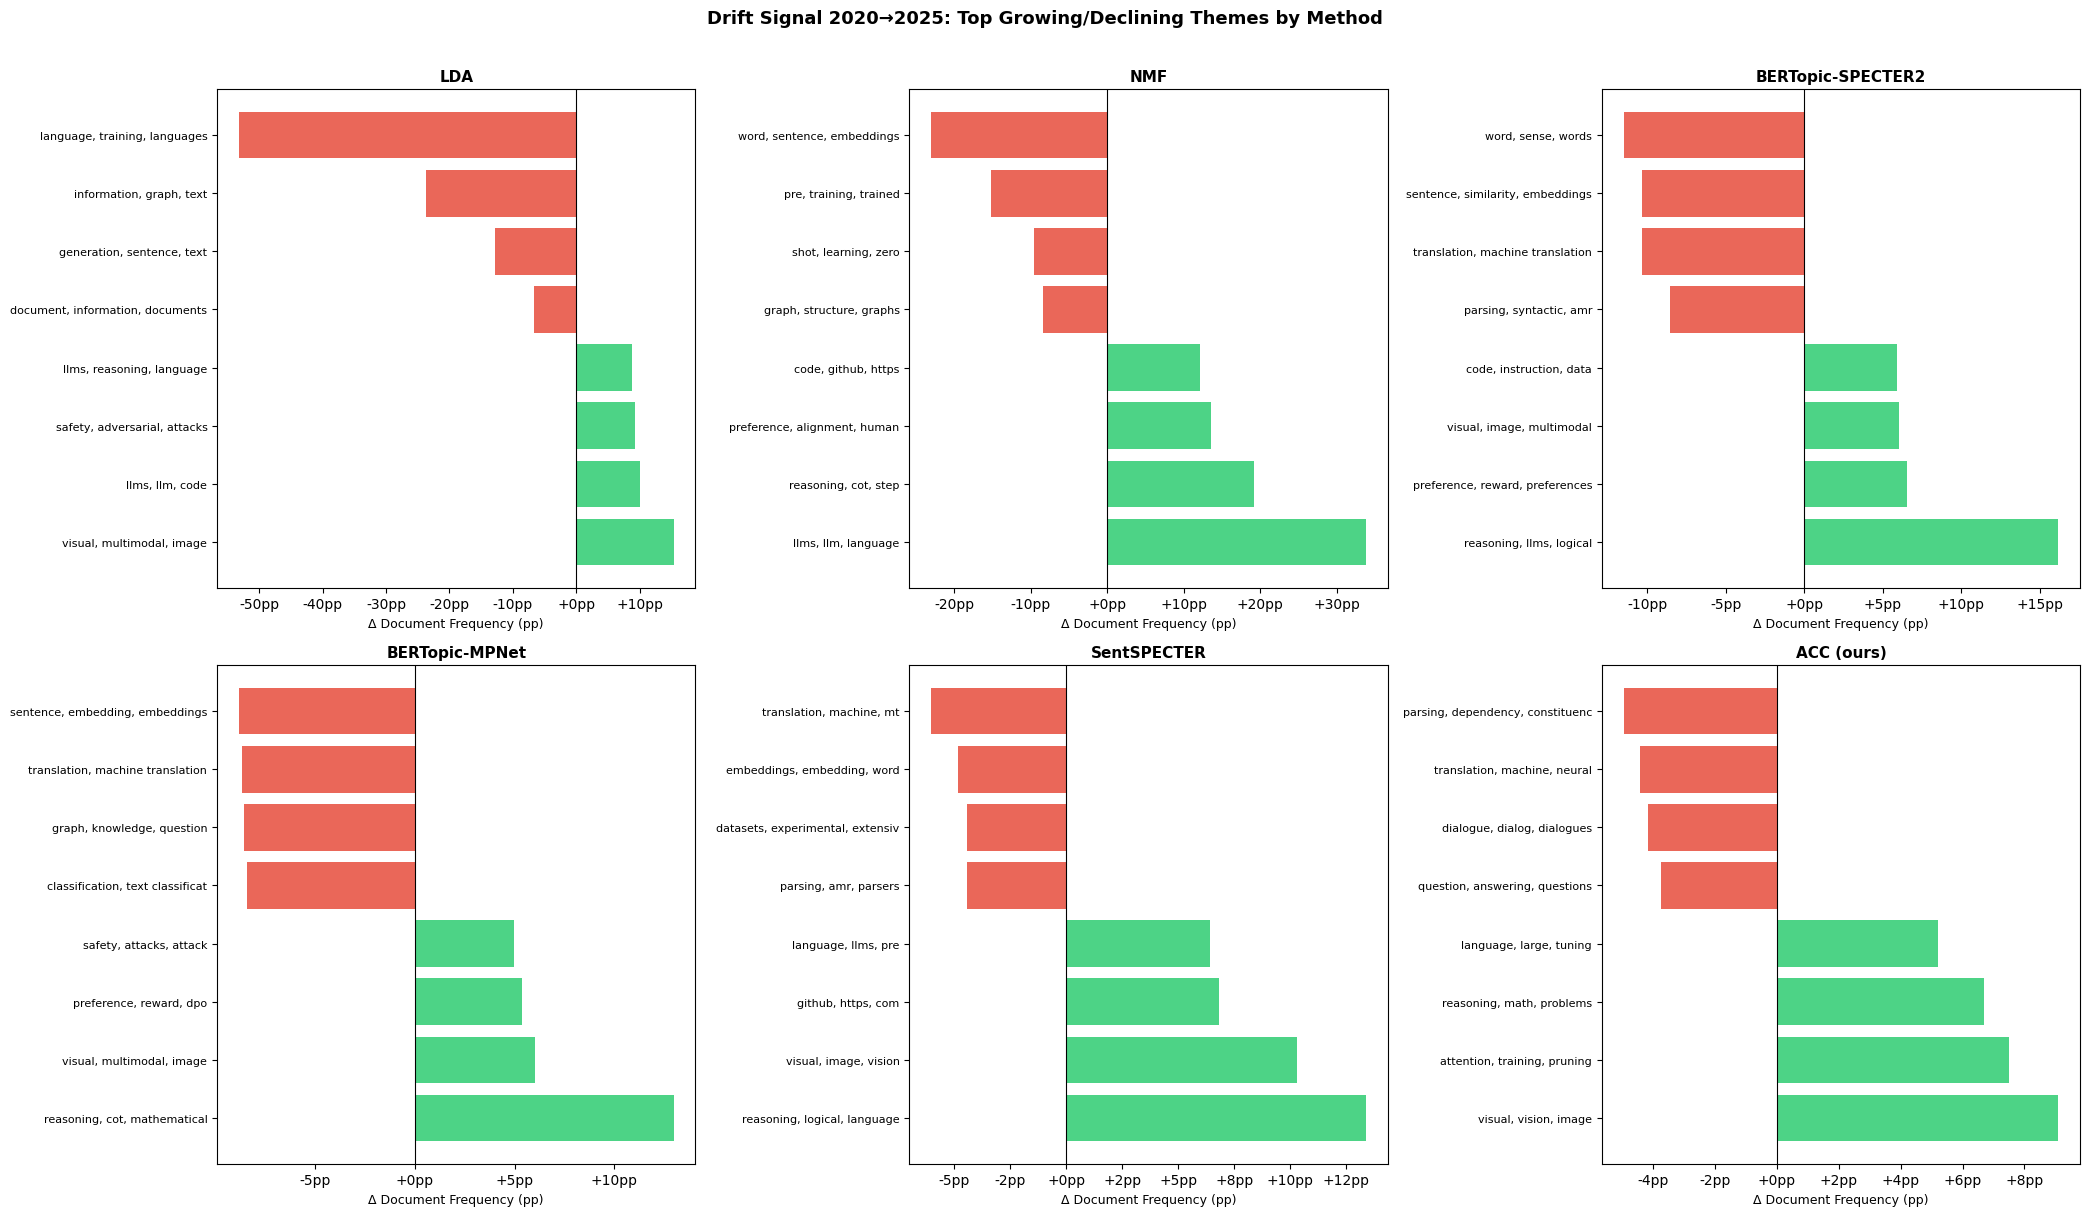

Figure saved.


In [32]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    method_order = ['lda', 'nmf', 'bertopic', 'bertopic_general', 'sentspecter', 'acc']
    display_names = {
        'lda': 'LDA', 'nmf': 'NMF', 'bertopic': 'BERTopic-SPECTER2',
        'bertopic_general': 'BERTopic-MPNet',
        'sentspecter': 'SentSPECTER',
        'acc': 'ACC (ours)',
    }

    N_METHODS = len(method_order)
    N_COLS = 3
    N_ROWS = (N_METHODS + N_COLS - 1) // N_COLS
    TOP_N = 8
    COLORS = {'growing': '#2ecc71', 'declining': '#e74c3c'}

    fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 7, N_ROWS * 6))
    axes_flat = axes.flatten() if N_ROWS > 1 else axes

    for ax, method in zip(axes_flat, method_order):
        df_t = temporal[method]
        top_grow = df_t.head(TOP_N // 2)[['topic', 'delta']].copy()
        top_decl = df_t.tail(TOP_N // 2)[['topic', 'delta']].copy()
        combined = pd.concat([top_grow, top_decl]).reset_index(drop=True)

        colors = [COLORS['growing'] if v >= 0 else COLORS['declining'] for v in combined['delta']]
        labels = [t[:32] for t in combined['topic']]

        ax.barh(range(len(combined)), combined['delta'] * 100, color=colors, alpha=0.85)
        ax.set_yticks(range(len(combined)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Δ Document Frequency (pp)', fontsize=9)
        ax.set_title(display_names[method], fontsize=11, fontweight='bold')
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0f}pp'))

    # Hide any unused subplots
    for ax in axes_flat[N_METHODS:]:
        ax.set_visible(False)

    plt.suptitle('Drift Signal 2020→2025: Top Growing/Declining Themes by Method',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / 'drift_comparison_barh.pdf', bbox_inches='tight')
    plt.savefig(ARTIFACTS_DIR / 'drift_comparison_barh.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Figure saved.')


## 12. Inflection Point Analysis (2020-2025, Variant A)

Variant A tracks fixed ACC cluster IDs across years and measures changes in
document prevalence for the selected clusters.

Running inflection analysis for ACC clusters (2020-2025)...
direction  cluster_id                      cluster_name  kendall_tau  kendall_p  inflection_year
   rising           6             visual, vision, image     1.000000   0.002778             2022
   rising          56      attention, training, pruning     0.466667   0.272222             2020
   rising          72         reasoning, math, problems     0.966092   0.007410             2022
declining          54 parsing, dependency, constituency    -0.966092   0.007410             2021
declining          43      translation, machine, neural    -0.866667   0.016667             2022
declining          11       dialogue, dialog, dialogues    -0.552052   0.125971             2023

Saved to artifacts/baseline/inflection_points_acc.csv


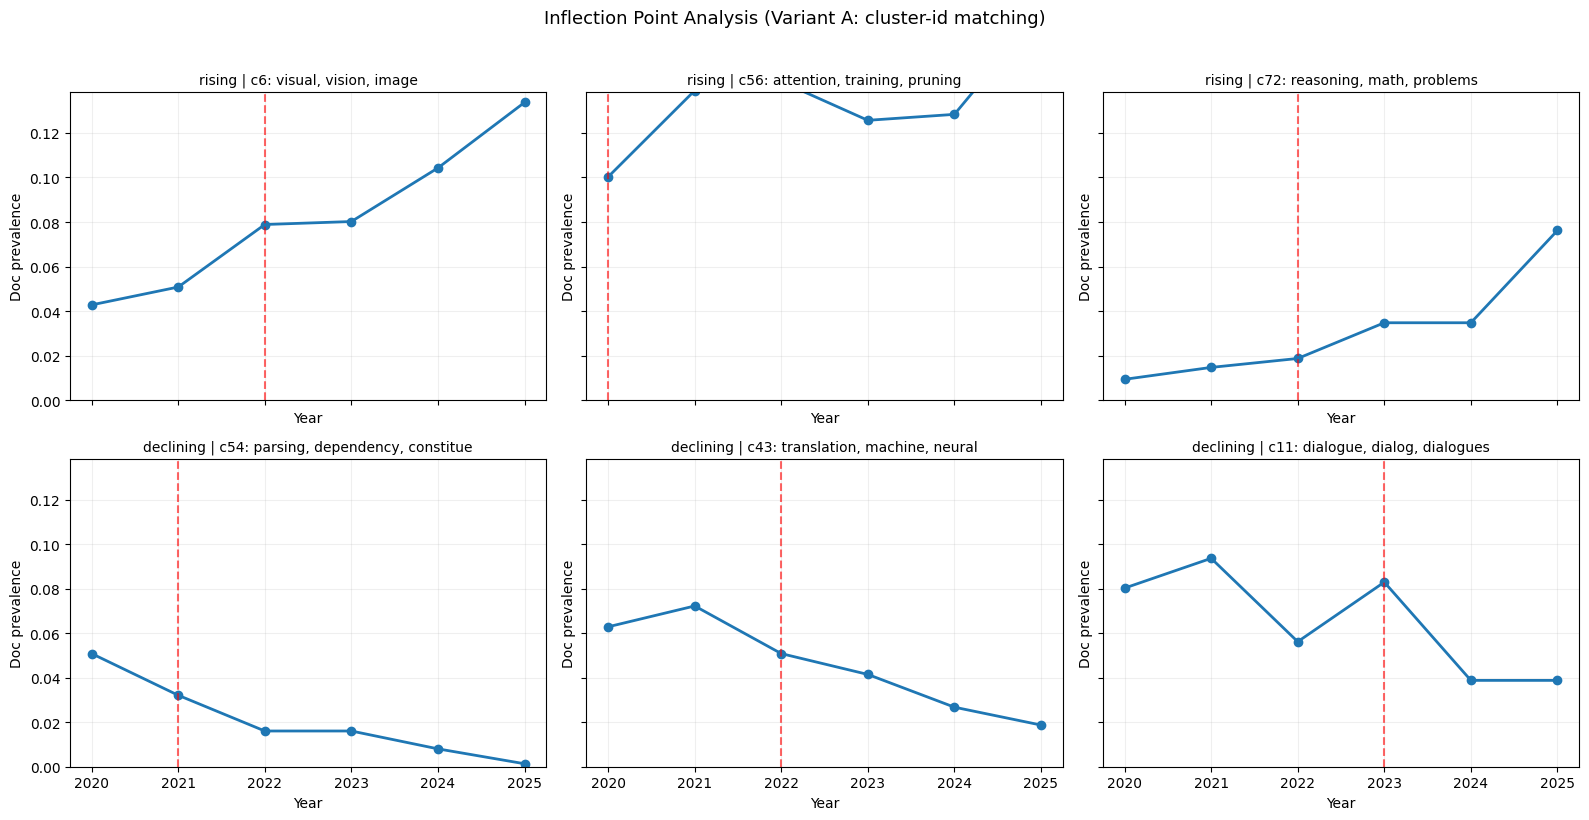

Saved figures: artifacts/baseline/inflection_points_acc.(png|pdf)


In [33]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    from scipy.stats import kendalltau

    def pettitt_test(series: list[float]) -> tuple[int, float]:
        """Return (change_index, approx_p_value) for Pettitt change-point test."""
        x = np.asarray(series, dtype=float)
        n = len(x)
        if n < 3:
            return -1, np.nan

        U = np.zeros(n)
        for k in range(n):
            s = 0
            for i in range(k + 1):
                for j in range(k + 1, n):
                    if x[i] > x[j]:
                        s += 1
                    elif x[i] < x[j]:
                        s -= 1
            U[k] = s

        k_star = int(np.argmax(np.abs(U)))
        K = np.max(np.abs(U))
        p = 2.0 * np.exp((-6.0 * (K ** 2)) / (n ** 3 + n ** 2))
        return k_star, float(min(1.0, p))

    def detect_inflection_by_cluster_ids(
        df_acc_eval: pd.DataFrame,
        cluster_ids: list[int],
        year_totals: dict[int, int],
        method_name: str = 'acc',
    ) -> dict:
        """
        Variant A: cluster-id based matching (simple and deterministic).
        Inputs:
          - df_acc_eval columns: paper_id, year, cluster
          - cluster_ids: list of target cluster IDs
          - year_totals: dict {year: n_eval_papers}
        """
        years_sorted = sorted(year_totals.keys())
        selected = df_acc_eval[df_acc_eval['cluster'].isin(cluster_ids)].copy()

        prevalence = {}
        for yr in years_sorted:
            denom = year_totals.get(yr, 0)
            num = selected.loc[selected['year'] == yr, 'paper_id'].nunique()
            prevalence[yr] = (num / denom) if denom > 0 else 0.0

        series = [prevalence[y] for y in years_sorted]
        tau, p_tau = kendalltau(years_sorted, series)

        cp_idx, p_cp = pettitt_test(series)
        inflection_year = years_sorted[cp_idx] if cp_idx >= 0 else None

        baseline = series[0] if series else 0.0
        first_2x_year = None
        if baseline > 0:
            for y, v in zip(years_sorted, series):
                if v >= 2.0 * baseline:
                    first_2x_year = y
                    break

        return {
            'method': method_name,
            'cluster_ids': cluster_ids,
            'kendall_tau': float(tau) if tau is not None else np.nan,
            'kendall_p': float(p_tau) if p_tau is not None else np.nan,
            'pettitt_p': p_cp,
            'inflection_year': inflection_year,
            'first_2x_year': first_2x_year,
            'prevalence_series': prevalence,
        }

    print('Running inflection analysis for ACC clusters (2020-2025)...')

    # Build ACC eval rows for robust year-wise paper prevalence.
    eval_ids = set(df_eval['paper_id'])
    df_acc_eval = df_acc[(df_acc['paper_id'].isin(eval_ids)) & (df_acc['cluster'] >= 0)][['paper_id', 'year', 'cluster']].copy()
    df_acc_eval = df_acc_eval.drop_duplicates(['paper_id', 'year', 'cluster'])

    year_totals = df_eval.groupby('year')['paper_id'].nunique().to_dict()
    years_sorted = sorted(year_totals.keys())

    # Use the same thresholded prevalence logic as temporal['acc'] but keep cluster IDs explicit.
    acc_active = (acc_doc_probs >= 0.1).astype(np.int8)
    mask_2020 = (df_eval['year'].values == 2020)
    mask_2025 = (df_eval['year'].values == 2025)
    df_2020 = acc_active[mask_2020].mean(axis=0)
    df_2025 = acc_active[mask_2025].mean(axis=0)
    delta = df_2025 - df_2020

    top_rising_idx = np.argsort(delta)[-3:][::-1]
    top_declining_idx = np.argsort(delta)[:3]

    target_specs = []
    for idx in top_rising_idx:
        target_specs.append({
            'direction': 'rising',
            'cluster_id': int(all_clusters[idx]),
            'cluster_name': acc_names[idx],
        })
    for idx in top_declining_idx:
        target_specs.append({
            'direction': 'declining',
            'cluster_id': int(all_clusters[idx]),
            'cluster_name': acc_names[idx],
        })

    inflection_rows = []
    for spec in target_specs:
        res = detect_inflection_by_cluster_ids(
            df_acc_eval=df_acc_eval,
            cluster_ids=[spec['cluster_id']],
            year_totals=year_totals,
            method_name='acc',
        )
        inflection_rows.append({
            'direction': spec['direction'],
            'cluster_id': spec['cluster_id'],
            'cluster_name': spec['cluster_name'],
            'kendall_tau': res['kendall_tau'],
            'kendall_p': res['kendall_p'],
            'pettitt_p': res['pettitt_p'],
            'inflection_year': res['inflection_year'],
            'first_2x_year': res['first_2x_year'],
            **{f'prev_{y}': res['prevalence_series'].get(y, np.nan) for y in years_sorted},
        })

    inflection_df = pd.DataFrame(inflection_rows)
    inflection_df.to_csv(ARTIFACTS_DIR / 'inflection_points_acc.csv', index=False)
    print(inflection_df[['direction', 'cluster_id', 'cluster_name', 'kendall_tau', 'kendall_p', 'inflection_year']].to_string(index=False))
    print('\nSaved to artifacts/baseline/inflection_points_acc.csv')

    # Plot trajectories with detected inflection years.
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
    axes = axes.flatten()
    for ax, row in zip(axes, inflection_rows):
        series = [row[f'prev_{y}'] for y in years_sorted] if f'prev_{years_sorted[0]}' in row else [np.nan]*len(years_sorted)
        ax.plot(years_sorted, series, marker='o', linewidth=2)
        if pd.notna(row['inflection_year']):
            ax.axvline(int(row['inflection_year']), color='red', linestyle='--', alpha=0.6, linewidth=1.5)
        ax.set_title(f"{row['direction']} | c{row['cluster_id']}: {row['cluster_name'][:30]}", fontsize=10)
        ax.grid(alpha=0.2)
        ax.set_ylim(bottom=0)

    for ax in axes:
        ax.set_xlabel('Year')
        ax.set_ylabel('Doc prevalence')

    plt.suptitle('Inflection Point Analysis (Variant A: cluster-id matching)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / 'inflection_points_acc.png', dpi=150, bbox_inches='tight')
    plt.savefig(ARTIFACTS_DIR / 'inflection_points_acc.pdf', bbox_inches='tight')
    plt.show()
    print('Saved figures: artifacts/baseline/inflection_points_acc.(png|pdf)')

## 13. Summary Comparison Table

In [34]:
if not (HAS_RAW and HAS_STOP):
    print('[skipped] depends on data/raw abstracts and/or data/external SToP taxonomy (absent in the public bundle) — see README §Data')
else:
    # Constants required by downstream cells (heatmap, FR, LaTeX).
    lda_noise          = 0.0
    nmf_noise          = 0.0
    bt_noise           = (np.array(bertopic_topics)[eval_mask] == -1).mean()
    bt_general_noise   = (np.array(bertopic_general_topics)[eval_mask] == -1).mean()
    sent_noise         = sent_noise_frac
    sent_top30_noise_val = float(globals().get('sent_top30_noise', np.nan))
    acc_noise          = (acc_doc_topics.sum(axis=1) == 0).mean()
    top30_noise        = (acc_top30_doc_topics.sum(axis=1) == 0).mean()

    # METHODS_ORDER already defined in the top-30 cell; METHOD_LABELS defined here.
    METHOD_LABELS = [
        'LDA', 'NMF', 'BERTopic-SPECTER2', 'BERTopic-general (MPNet)',
        'SentSPECTER', 'SentSPECTER-top30', 'ACC (ours)', 'ACC-top30',
    ]

    n_train_papers  = len(df_papers)
    n_eval_papers   = len(df_eval)
    n_claim_papers  = df_claims['paper_id'].nunique()
    n_stop_2020_2021 = int(eval_stop_year_mask.sum())

    N_TOPICS_MAP = {
        'lda': N_TOPICS, 'nmf': N_TOPICS, 'bertopic': n_bt_topics,
        'bertopic_general': n_bt_general_topics,
        'sentspecter': n_sent_cls, 'sentspecter_top30': SENT_TOP30_N,
        'acc': n_acc_clusters, 'acc_top30': TOP30_N,
    }
    TRAIN_CORPUS_MAP = {
        'lda':               f'{n_train_papers} papers',
        'nmf':               f'{n_train_papers} papers',
        'bertopic':          f'{n_train_papers} papers',
        'bertopic_general':  f'{n_train_papers} papers',
        'sentspecter':       f'{n_train_papers} papers (sents)',
        'sentspecter_top30': f'{n_train_papers} papers (sents)',
        'acc':               f'{n_claim_papers} papers with claims',
        'acc_top30':         f'{n_claim_papers} papers with claims',
    }
    COH_REF_MAP = {
        'lda': 'abstracts', 'nmf': 'abstracts', 'bertopic': 'abstracts',
        'bertopic_general': 'abstracts',
        'sentspecter': 'abstracts', 'sentspecter_top30': 'abstracts',
        'acc': 'paper claims', 'acc_top30': 'paper claims',
    }
    noise_vals = [
        lda_noise, nmf_noise, bt_noise, bt_general_noise,
        sent_noise, sent_top30_noise_val, acc_noise, top30_noise,
    ]


    def _fmt(v):
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return '—'
        return f'{v:.4f}'


    def _soft_cluster_purity_subset(
        doc_matrix: np.ndarray, subset_mask: np.ndarray, labels_subset: list
    ) -> float:
        """Soft cluster purity restricted to rows where subset_mask is True."""
        idx = np.where(subset_mask)[0]
        if len(idx) == 0:
            return np.nan
        purities = []
        for t in range(doc_matrix.shape[1]):
            weights = doc_matrix[idx, t]
            total_w = weights.sum()
            if total_w < 1e-6:
                continue
            label_w: dict[str, float] = {}
            for w, lbls in zip(weights, labels_subset):
                if w < 1e-6:
                    continue
                for lbl in lbls:
                    label_w[lbl] = label_w.get(lbl, 0.0) + float(w)
            if label_w:
                purities.append(max(label_w.values()) / total_w)
        return float(np.mean(purities)) if purities else np.nan


    # Strict SToP 2020-2021 scope check.
    stop_eval_years = set(df_eval.loc[eval_stop_year_mask, 'year'].unique().tolist())
    assert stop_eval_years.issubset({2020, 2021}), \
        f'Leakage in SToP scope: years={sorted(stop_eval_years)}'

    stop_true_labels_2020_2021 = df_eval.loc[eval_stop_year_mask, 'stop_labels'].tolist()
    assert len(stop_true_labels_2020_2021) == n_stop_2020_2021, 'SToP labels length mismatch'

    method_mats_eval = {
        'lda':               lda_eval,
        'nmf':               nmf_eval,
        'bertopic':          bt_eval,
        'bertopic_general':  bt_general_eval,
        'sentspecter':       sent_doc_probs,
        'sentspecter_top30': sent_top30_probs,
        'acc':               acc_doc_probs,
        'acc_top30':         acc_top30_probs,
    }

    # Purity on strict 2020-2021 SToP subset (used by FR cell).
    purity_stop_results = {
        m: _soft_cluster_purity_subset(
            method_mats_eval[m], eval_stop_year_mask, stop_true_labels_2020_2021
        )
        for m in METHODS_ORDER
    }

    # Global intrinsic table (no SToP-label-dependent ranking metrics — those live in FR).
    summary_global_table = pd.DataFrame({
        'Method':                  METHOD_LABELS,
        'N Topics':                [N_TOPICS_MAP[m]  for m in METHODS_ORDER],
        'Train corpus':            [TRAIN_CORPUS_MAP[m] for m in METHODS_ORDER],
        'Eval corpus (all years)': [f'{n_eval_papers} papers'] * len(METHODS_ORDER),
        'Coh. ref':                [COH_REF_MAP[m]   for m in METHODS_ORDER],
        'C_v':                     [coherence_results.get(m, {}).get('C_v')   for m in METHODS_ORDER],
        'NPMI':                    [coherence_results.get(m, {}).get('NPMI')  for m in METHODS_ORDER],
        'UMass':                   [coherence_results.get(m, {}).get('UMass') for m in METHODS_ORDER],
        'Diversity':               [diversity_results.get(m) for m in METHODS_ORDER],
        'Noise':                   noise_vals,
    })

    summary_global_print = summary_global_table.copy()
    for col in ['C_v', 'NPMI', 'UMass', 'Diversity', 'Noise']:
        summary_global_print[col] = summary_global_print[col].map(_fmt)

    print('=' * 120)
    print('GLOBAL TABLE — intrinsic metrics (SToP alignment metrics are in the canonical FR cell below)')
    print(f'Eval subset: {n_eval_papers} papers')
    print('=' * 120)
    print(summary_global_print.to_string(index=False))

    comparison_table = summary_global_table.copy()
    comparison_table.to_csv(ARTIFACTS_DIR / 'comparison_table.csv', index=False)
    print('\nSaved to artifacts/baseline/comparison_table.csv')


GLOBAL TABLE — intrinsic metrics (SToP alignment metrics are in the canonical FR cell below)
Eval subset: 4488 papers
                  Method  N Topics            Train corpus Eval corpus (all years)     Coh. ref    C_v   NPMI   UMass Diversity  Noise
                     LDA        30             6517 papers             4488 papers    abstracts 0.5028 0.0508 -2.3503    0.6467 0.0000
                     NMF        30             6517 papers             4488 papers    abstracts 0.6628 0.1261 -2.4789    0.8700 0.0000
       BERTopic-SPECTER2        52             6517 papers             4488 papers    abstracts 0.6991 0.1497 -2.4939    0.7404 0.2504
BERTopic-general (MPNet)        60             6517 papers             4488 papers    abstracts 0.6662 0.1309 -2.6420    0.7450 0.2141
             SentSPECTER       187     6517 papers (sents)             4488 papers    abstracts 0.5493 0.0655 -3.9044    0.5594 0.0274
       SentSPECTER-top30        30     6517 papers (sents)             4

In [35]:
if not (HAS_RAW and HAS_STOP):
    print('[skipped] depends on data/raw abstracts and/or data/external SToP taxonomy (absent in the public bundle) — see README §Data')
else:
    # ── Canonical evaluation metrics ── single source of truth for heatmap & LaTeX ──
    # Purity     : full SToP 2020-2021 set (well-defined even with zero rows)
    # LRAP, nDCG : repeated-CV on nonzero-row subset (ranking metrics require ≥1 topic)
    # V, PairF1  : hard assignment on the same nonzero-row subset
    from sklearn.model_selection import RepeatedKFold
    from sklearn.metrics import label_ranking_average_precision_score, ndcg_score, v_measure_score

    _k   = max(1, int(k_gt))
    _y   = y_stop.astype(np.float64)
    _ls  = labelset_stop

    _mats = {
        m: np.clip(np.nan_to_num(method_eval_mats_stop[m].astype(np.float64)), 0.0, None)
        for m in METHODS_ORDER
    }
    _nz = {m: _mats[m].sum(axis=1) > 0 for m in METHODS_ORDER}


    def _cv_nz(mat, y, k, nz):
        x, yy = mat[nz], y[nz]
        rkf = RepeatedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
        lv, dv = [], []
        for tr, te in rkf.split(x):
            p = learn_topic_to_label_matrix(x[tr], yy[tr], eps=1e-8)
            s = x[te] @ p
            lv.append(label_ranking_average_precision_score(yy[te], s))
            dv.append(ndcg_score(yy[te], s, k=k))
        return (float(np.mean(lv)), float(np.std(lv, ddof=1)),
                float(np.mean(dv)), float(np.std(dv, ddof=1)))


    print(f'Computing canonical evaluation metrics (SToP 2020-2021, k={_k})...')
    FR = {}
    for m in METHODS_ORDER:
        mat, nz = _mats[m], _nz[m]
        lm, ls_v, dm, ds_v = _cv_nz(mat, _y, _k, nz)
        xn, yn = mat[nz], _y[nz]
        hard = np.argmax(xn, axis=1)
        vm   = float(v_measure_score(_ls[nz], hard))
        _, _, pf = pairwise_f1_sampled(yn.astype(np.int8), hard,
                                       n_pairs=200_000, random_state=RANDOM_STATE)
        FR[m] = dict(
            K    = N_TOPICS_MAP[m],
            Cv   = coherence_results.get(m, {}).get('C_v'),
            NPMI = coherence_results.get(m, {}).get('NPMI'),
            Div  = diversity_results.get(m),
            Noise= noise_vals[METHODS_ORDER.index(m)],   # fraction 0-1
            Cov  = float(nz.mean()),                     # fraction 0-1
            Pur  = purity_stop_results.get(m),
            Lm=lm, Ls=ls_v, Dm=dm, Ds=ds_v, V=vm, PF=pf,
        )
        print(f'  {m:18s}  Pur={FR[m]["Pur"]:.4f}  Cov={FR[m]["Cov"]:.1%}'
              f'  LRAP={lm:.4f}  nDCG@{_k}={dm:.4f}  V={vm:.4f}  PF={pf:.4f}')

    print(f'\nFR dict ready ({len(FR)} methods) — single source of truth for heatmap and LaTeX table.')

    # Save corrected SToP alignment CSV (replaces the stale stop_alignment_table.csv).
    _stop_align = pd.DataFrame({
        'Method':                  METHOD_LABELS,
        'K':                       [FR[m]['K']                       for m in METHODS_ORDER],
        'Purity':                  [FR[m]['Pur']                     for m in METHODS_ORDER],
        'Coverage':                [FR[m]['Cov']                     for m in METHODS_ORDER],
        'LRAP_mean':               [FR[m]['Lm']                      for m in METHODS_ORDER],
        'LRAP_std':                [FR[m]['Ls']                      for m in METHODS_ORDER],
        f'nDCG@{_k}_mean':         [FR[m]['Dm']                      for m in METHODS_ORDER],
        f'nDCG@{_k}_std':          [FR[m]['Ds']                      for m in METHODS_ORDER],
        'V_measure':               [FR[m]['V']                       for m in METHODS_ORDER],
        'PairF1':                  [FR[m]['PF']                      for m in METHODS_ORDER],
    })
    _stop_align.to_csv(ARTIFACTS_DIR / 'stop_alignment_table.csv', index=False)
    print(f'Saved → artifacts/baseline/stop_alignment_table.csv')


Computing canonical evaluation metrics (SToP 2020-2021, k=1)...
  lda                 Pur=0.2460  Cov=100.0%  LRAP=0.5105  nDCG@1=0.3329  V=0.2723  PF=0.1678
  nmf                 Pur=0.2935  Cov=100.0%  LRAP=0.5852  nDCG@1=0.4450  V=0.3239  PF=0.1859
  bertopic            Pur=0.3237  Cov=100.0%  LRAP=0.6506  nDCG@1=0.5151  V=0.4686  PF=0.2894
  bertopic_general    Pur=0.3267  Cov=100.0%  LRAP=0.6508  nDCG@1=0.5087  V=0.4565  PF=0.2339
  sentspecter         Pur=0.6544  Cov=97.9%  LRAP=0.6679  nDCG@1=0.5403  V=0.5319  PF=0.2677
  sentspecter_top30   Pur=0.4721  Cov=79.2%  LRAP=0.6367  nDCG@1=0.5117  V=0.4711  PF=0.3651
  acc                 Pur=0.6888  Cov=83.9%  LRAP=0.6741  nDCG@1=0.5795  V=0.5705  PF=0.3607
  acc_top30           Pur=0.6181  Cov=70.6%  LRAP=0.6935  nDCG@1=0.5956  V=0.5522  PF=0.4033

FR dict ready (8 methods) — single source of truth for heatmap and LaTeX table.
Saved → artifacts/baseline/stop_alignment_table.csv


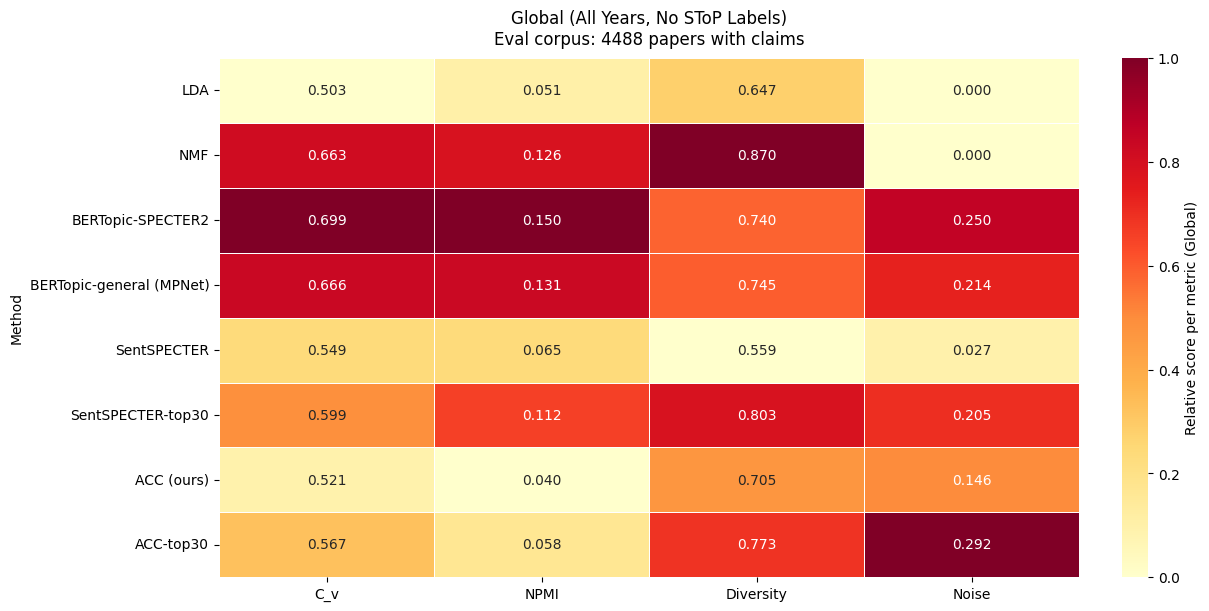

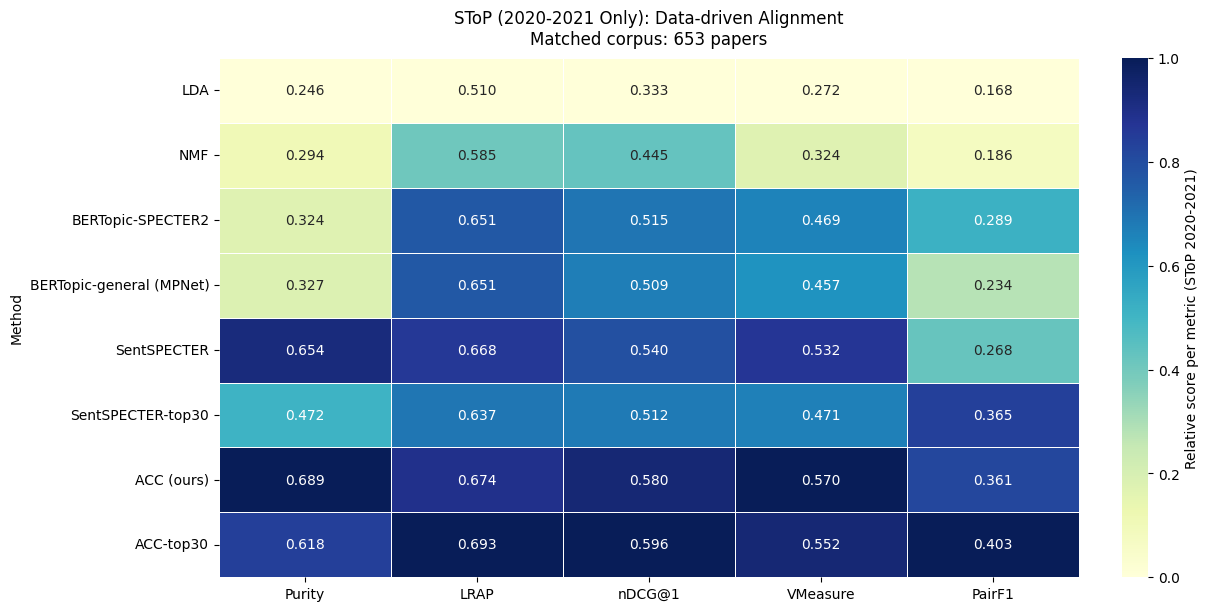

Heatmaps saved: artifacts/baseline/comparison_heatmap_global.(pdf|png) and comparison_heatmap_stop.(pdf|png)


In [36]:
if not (HAS_RAW and HAS_STOP):
    print('[skipped] depends on data/raw abstracts and/or data/external SToP taxonomy (absent in the public bundle) — see README §Data')
else:
    # Visual summary heatmaps — reads from FR (canonical metrics, computed above).
    ndcg_col_name = f'nDCG@{k_gt}'

    summary_global = pd.DataFrame({
        'Method':    METHOD_LABELS,
        'C_v':       [FR[m]['Cv']    for m in METHODS_ORDER],
        'NPMI':      [FR[m]['NPMI']  for m in METHODS_ORDER],
        'Diversity': [FR[m]['Div']   for m in METHODS_ORDER],
        'Noise':     [FR[m]['Noise'] for m in METHODS_ORDER],
    }).set_index('Method').astype(float)

    summary_stop = pd.DataFrame({
        'Method':           METHOD_LABELS,
        'Purity':   [FR[m]['Pur'] for m in METHODS_ORDER],
        'LRAP':            [FR[m]['Lm']  for m in METHODS_ORDER],
        ndcg_col_name:     [FR[m]['Dm']  for m in METHODS_ORDER],
        'VMeasure': [FR[m]['V']   for m in METHODS_ORDER],
        'PairF1':   [FR[m]['PF']  for m in METHODS_ORDER],
    }).set_index('Method').astype(float)

    def _col_minmax(df: pd.DataFrame) -> pd.DataFrame:
        cmin = df.min(axis=0)
        cmax = df.max(axis=0)
        crng = (cmax - cmin).replace(0, 1.0)
        return (df - cmin) / crng

    summary_global_norm = _col_minmax(summary_global)
    summary_stop_norm   = _col_minmax(summary_stop)

    # 1) Global heatmap (intrinsic metrics only).
    fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
    sns.heatmap(
        summary_global_norm,
        annot=summary_global,
        fmt='.3f',
        cmap='YlOrRd',
        linewidths=0.5,
        ax=ax,
        cbar_kws={'label': 'Relative score per metric (Global)'},
    )
    ax.set_title(
        f'Global (All Years, No SToP Labels)\nEval corpus: {len(df_eval)} papers with claims',
        fontsize=12,
        pad=10,
    )
    plt.savefig(ARTIFACTS_DIR / 'comparison_heatmap_global.pdf', bbox_inches='tight')
    plt.savefig(ARTIFACTS_DIR / 'comparison_heatmap_global.png', bbox_inches='tight', dpi=150)
    plt.show()

    # 2) SToP heatmap (strict 2020-2021; ranking metrics on nonzero-row subset).
    fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
    sns.heatmap(
        summary_stop_norm,
        annot=summary_stop,
        fmt='.3f',
        cmap='YlGnBu',
        linewidths=0.5,
        ax=ax,
        cbar_kws={'label': 'Relative score per metric (SToP 2020-2021)'},
    )
    ax.set_title(
        f'SToP (2020-2021 Only): Data-driven Alignment\nMatched corpus: {int(eval_stop_year_mask.sum())} papers',
        fontsize=12,
        pad=10,
    )
    plt.savefig(ARTIFACTS_DIR / 'comparison_heatmap_stop.pdf', bbox_inches='tight')
    plt.savefig(ARTIFACTS_DIR / 'comparison_heatmap_stop.png', bbox_inches='tight', dpi=150)
    plt.show()

    print('Heatmaps saved: artifacts/baseline/comparison_heatmap_global.(pdf|png) and comparison_heatmap_stop.(pdf|png)')


In [37]:
if not (HAS_RAW and HAS_STOP):
    print('[skipped] depends on data/raw abstracts and/or data/external SToP taxonomy (absent in the public bundle) — see README §Data')
else:
    # ── LaTeX table generation — reads from FR (do not compute metrics here) ──────
    DISP = {
        'lda'              : 'LDA',
        'nmf'              : 'NMF',
        'bertopic'         : 'BERTopic-SPECTER2',
        'bertopic_general' : 'BERTopic-MPNet',
        'sentspecter'      : 'SentSPECTER',
        'sentspecter_top30': 'SentSPECTER-top30',
        'acc'              : r'ACC \textit{(ours)}',
        'acc_top30'        : 'ACC-top30',
    }
    GROUPS = [
        ['lda', 'nmf'],
        ['bertopic', 'bertopic_general'],
        ['sentspecter', 'sentspecter_top30'],
        ['acc', 'acc_top30'],
    ]
    grp_id = {m: i for i, g in enumerate(GROUPS) for m in g}

    # Best value per column (all higher-is-better).
    BCOLS = ['Cv', 'NPMI', 'Div', 'Pur', 'Lm', 'Dm', 'V', 'PF']
    EPS   = 5e-5
    bv = {}
    for col in BCOLS:
        vals = [FR[m][col] for m in METHODS_ORDER
                if FR[m].get(col) is not None and not np.isnan(float(FR[m][col]))]
        if vals:
            bv[col] = max(vals)


    def _f(v, col, prec=4):
        if v is None or np.isnan(float(v)):
            return '{---}'
        s = f'{v:.{prec}f}'
        return (r'\textbf{' + s + '}') if (col in bv and abs(v - bv[col]) < EPS) else s


    def _fpm(mv, sv, col):
        if mv is None or np.isnan(float(mv)):
            return '{---}'
        m_s, s_s = f'{mv:.4f}', f'{sv:.4f}'
        bold = col in bv and abs(mv - bv[col]) < EPS
        mean_part = (r'\textbf{' + m_s + '}') if bold else m_s
        return mean_part + r'{\scriptsize\,$\pm$\,' + s_s + '}'


    ndcg_h = f'nDCG@{_k}'

    tex_lines = [
        r'\begin{table*}[p]',
        r'\centering',
        r'\small',
        r'\setlength{\tabcolsep}{4pt}',
        (r'\caption{\textbf{Full method comparison across all evaluation dimensions.} '
         r'\emph{Intrinsic} metrics (C$_v$, NPMI, Div.)\ are computed on the full evaluation '
         r'corpus (4\,488 papers, all years). '
         r'\emph{SToP alignment} uses the 2020--2021 matched subset (653 papers): '
         r'Purity is computed on all matched papers; '
         r'LRAP, ' + ndcg_h + r', V-measure, and PairF1 are computed on the subset of '
         r'documents assigned to at least one topic cluster (Coverage). '
         r'Methods are grouped by representation granularity: '
         r'bag-of-words (LDA, NMF), abstract-level neural (BERTopic variants), '
         r'sentence-level neural (SentSPECTER variants), '
         r'and claim-level neural (ACC variants, ours). '
         r'\textbf{Bold}: best value in each column.}'),
        r'\label{tab:full_comparison_appendix}',
        r'\begin{tabular}{l r | r r r r | r r r r r r}',
        r'\toprule',
        (r' & & \multicolumn{4}{c|}{\textbf{Intrinsic (all years)}}'
         r' & \multicolumn{6}{c}{\textbf{SToP Alignment (2020--2021)}} \\'),
        r'\cmidrule(lr){3-6}\cmidrule(l){7-12}',
        (r'\textbf{Method} & $K$ & C$_v$ & NPMI & Div. & Noise\%'
         r' & Pur. & Cov.\% & LRAP & ' + ndcg_h + r' & V & PairF1 \\'),
        r'\midrule',
    ]

    prev_g = grp_id[METHODS_ORDER[0]]
    for m in METHODS_ORDER:
        if grp_id[m] != prev_g:
            tex_lines.append(r'\midrule')
        prev_g = grp_id[m]
        r = FR[m]
        tex_lines.append(' & '.join([
            DISP[m],
            str(r['K']),
            _f(r['Cv'],  'Cv'),
            _f(r['NPMI'], 'NPMI'),
            _f(r['Div'], 'Div', prec=3),
            f'{r["Noise"]*100:.1f}',
            _f(r['Pur'], 'Pur'),
            f'{r["Cov"]*100:.1f}',
            _fpm(r['Lm'], r['Ls'], 'Lm'),
            _fpm(r['Dm'], r['Ds'], 'Dm'),
            _f(r['V'],  'V'),
            _f(r['PF'], 'PF'),
        ]) + r' \\')

    tex_lines += [r'\bottomrule', r'\end{tabular}', r'\end{table*}']
    tex_str = '\n'.join(tex_lines)

    print('\n' + '=' * 80)
    print(tex_str)
    print('=' * 80)

    out = ARTIFACTS_DIR / 'full_comparison_table.tex'
    out.write_text(tex_str, encoding='utf-8')
    print(f'\nSaved → {out}')



\begin{table*}[p]
\centering
\small
\setlength{\tabcolsep}{4pt}
\caption{\textbf{Full method comparison across all evaluation dimensions.} \emph{Intrinsic} metrics (C$_v$, NPMI, Div.)\ are computed on the full evaluation corpus (4\,488 papers, all years). \emph{SToP alignment} uses the 2020--2021 matched subset (653 papers): Purity is computed on all matched papers; LRAP, nDCG@1, V-measure, and PairF1 are computed on the subset of documents assigned to at least one topic cluster (Coverage). Methods are grouped by representation granularity: bag-of-words (LDA, NMF), abstract-level neural (BERTopic variants), sentence-level neural (SentSPECTER variants), and claim-level neural (ACC variants, ours). \textbf{Bold}: best value in each column.}
\label{tab:full_comparison_appendix}
\begin{tabular}{l r | r r r r | r r r r r r}
\toprule
 & & \multicolumn{4}{c|}{\textbf{Intrinsic (all years)}} & \multicolumn{6}{c}{\textbf{SToP Alignment (2020--2021)}} \\
\cmidrule(lr){3-6}\cmidrule(l){7-12}
\te